20251006 Keep only 4 indicators to check rMZR behaviors

  IC3392: HII=14884 pixels
  NGC4064: HII=6820 pixels
  NGC4192: HII=145934 pixels
  NGC4293: HII=3854 pixels
  NGC4192: HII=145934 pixels
  NGC4293: HII=3854 pixels
  NGC4298: HII=156350 pixels
  NGC4330: HII=42566 pixels
  NGC4383: excluded from Σ_SFR-binned analysis
  NGC4298: HII=156350 pixels
  NGC4330: HII=42566 pixels
  NGC4383: excluded from Σ_SFR-binned analysis
  NGC4396: HII=81728 pixels
  NGC4419: HII=6886 pixels
  NGC4396: HII=81728 pixels
  NGC4419: HII=6886 pixels
  NGC4457: HII=6000 pixels
  NGC4457: HII=6000 pixels
  NGC4501: HII=260854 pixels
  NGC4522: HII=39354 pixels
  NGC4501: HII=260854 pixels
  NGC4522: HII=39354 pixels
  NGC4694: HII=2585 pixels
  NGC4698: HII=10042 pixels
  NGC4694: HII=2585 pixels
  NGC4698: HII=10042 pixels

Total combined pixels (HII): 777857
Using uniform y-axis range: 8.0 to 9.3

Processing D16 calibration for HII regions:
  HII D16 range: 7.906 to 9.229
  Total valid bins: 14

Processing PG16 calibration for HII regions:
  HII PG16 range

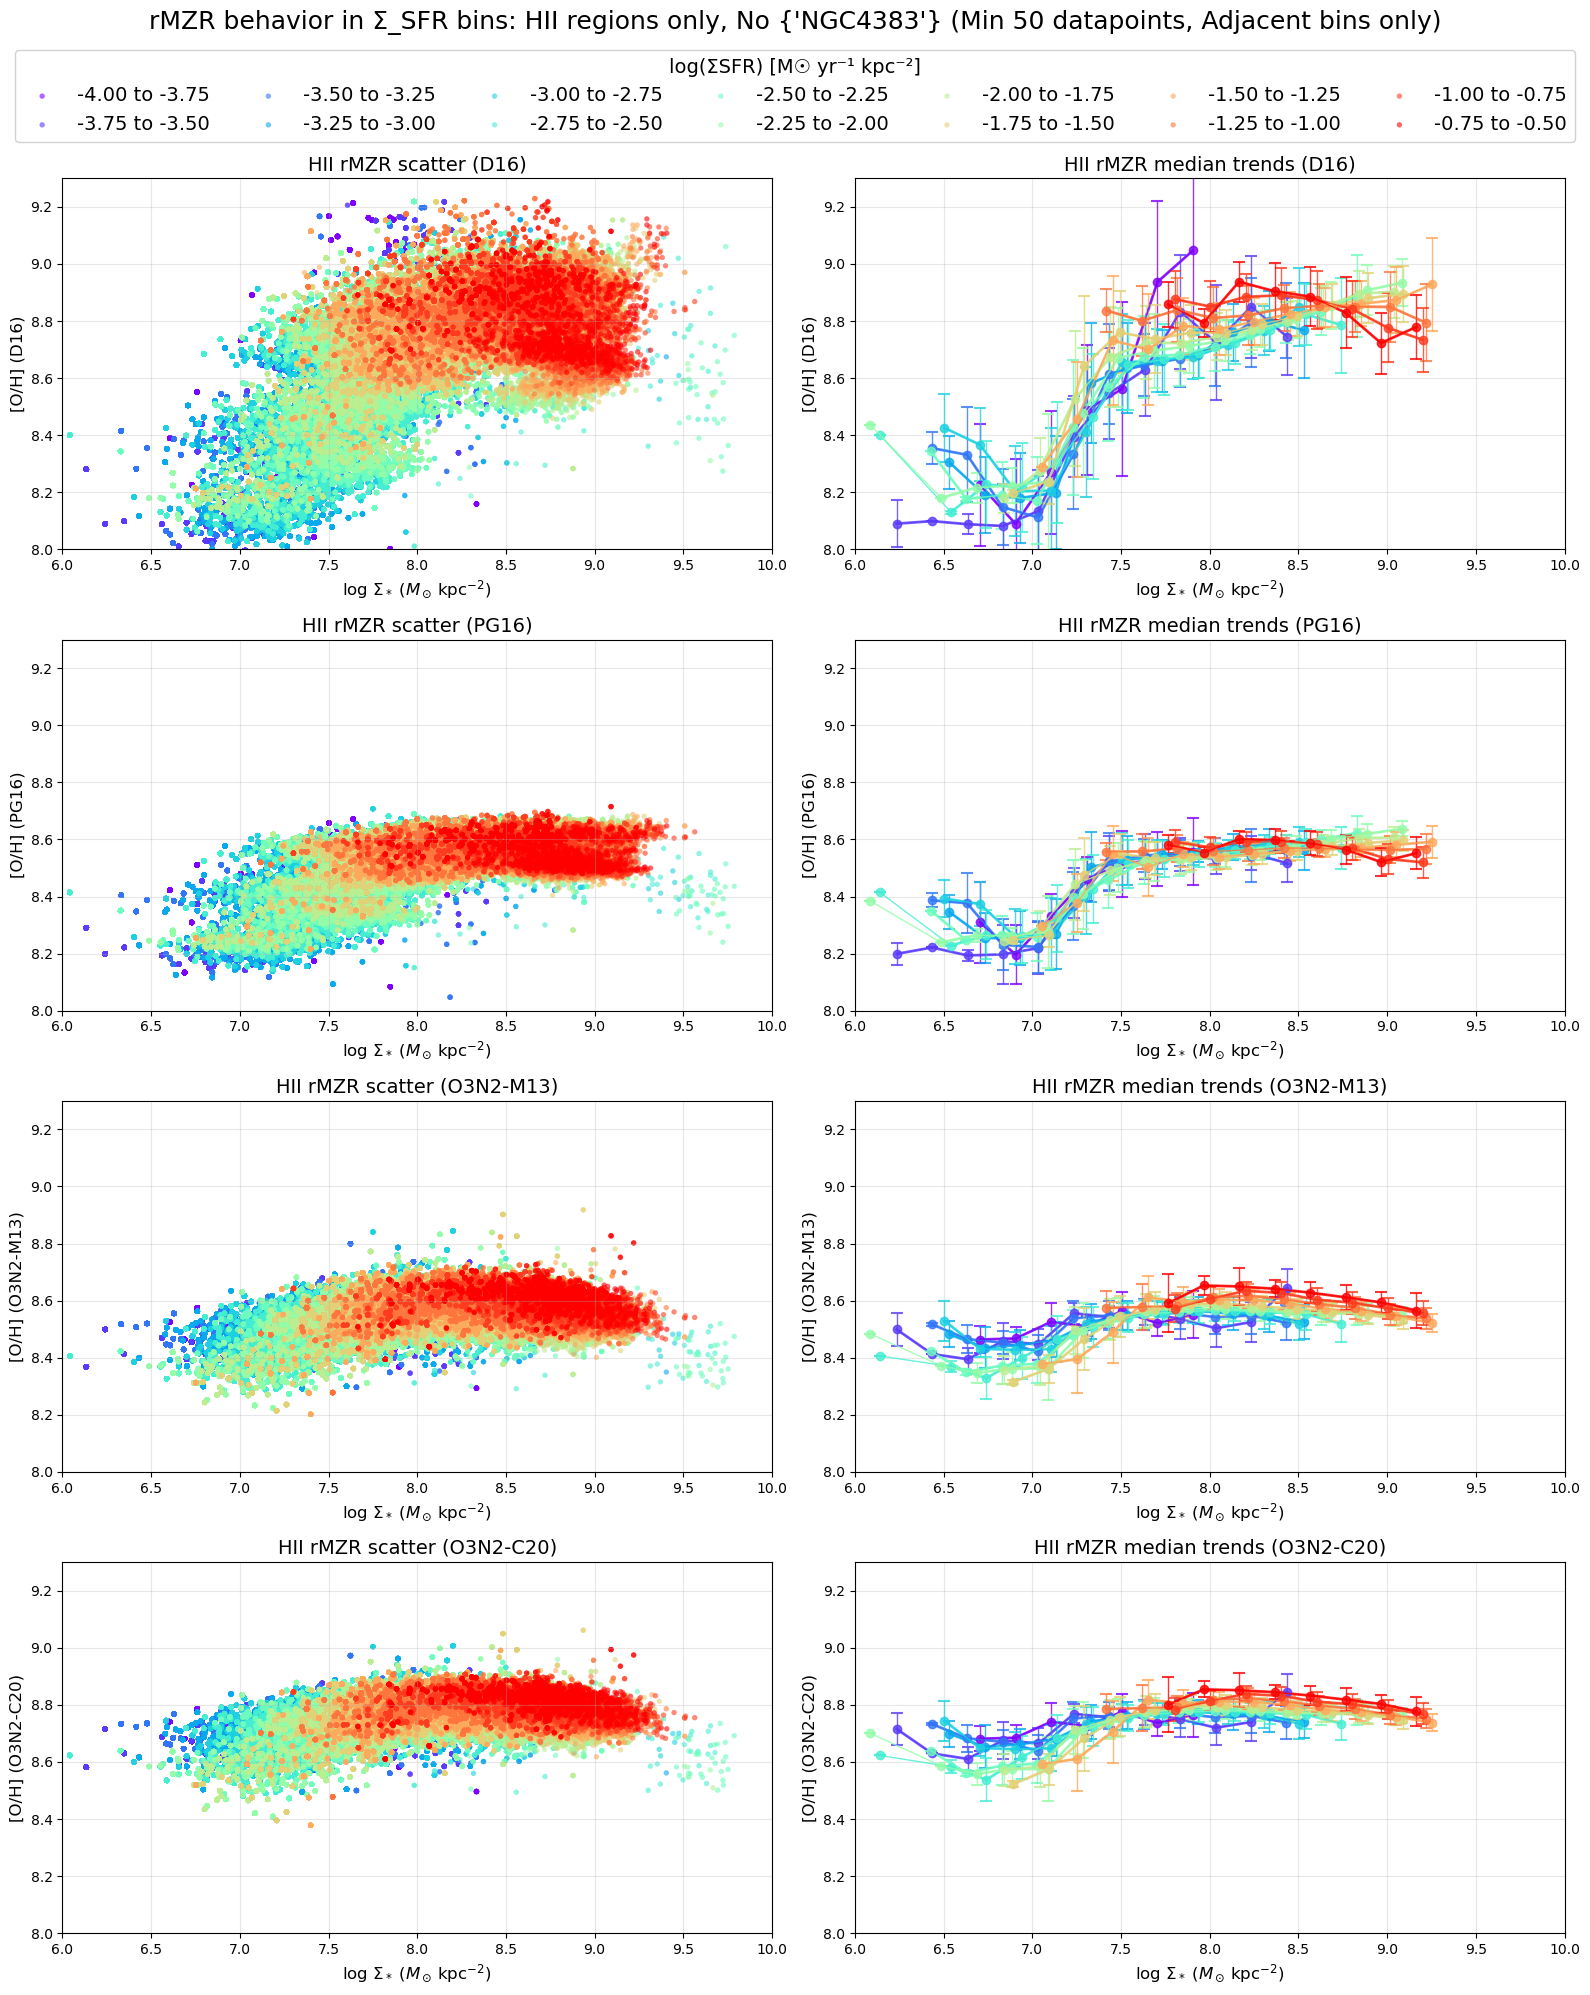


Successfully created combined 4x2 subplot figure showing HII regions from 13 galaxies
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Excluded: NGC4383


In [1]:
# ------------------------------------------------------------------
# Combined Analysis: rMZR behavior in Σ_SFR bins - HII regions only
# Collect all spaxels from all galaxies
# 4 rows x 2 columns: Each row shows 1 indicator (scatter on left, median on right)
# 4 calibrations: D16, PG16, O3N2-M13, O3N2-C20
# Row 1: D16 (scatter, median)
# Row 2: PG16 (scatter, median)
# Row 3: O3N2-M13 (scatter, median)
# Row 4: O3N2-C20 (scatter, median)
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats

def load_maps_all_calibrations(gal):
    """Load all metallicity calibrations for HII regions"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        # HII regions
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_d16_HII = h['O_H_D16_HII'].data
        oh_pg16_HII = h['O_H_PG16_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
        oh_o3n2_c20_HII = h['O_H_O3N2_C20_HII'].data
    return (sigM, sigSFR_HII, oh_d16_HII, oh_pg16_HII, oh_o3n2_m13_HII, oh_o3n2_c20_HII)

def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=50):
    """Calculate median and std in stellar mass bins - only keep bins with >= 50 unique datapoints"""
    # Define mass bins
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    mass_bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    mass_bin_centers = (mass_bin_edges[:-1] + mass_bin_edges[1:]) / 2
    
    medians = []
    stds = []
    counts = []
    valid_centers = []
    valid_bin_indices = []
    
    for i, (bin_start, bin_end) in enumerate(zip(mass_bin_edges[:-1], mass_bin_edges[1:])):
        # Select data in this mass bin
        in_mass_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_mass_bin]
        
        if len(y_in_bin) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(mass_bin_centers[i])
            valid_bin_indices.append(i)
    
    return (np.array(valid_centers), np.array(medians), np.array(stds), 
            np.array(counts), np.array(valid_bin_indices))

# Get all galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

# Galaxies to exclude entirely
excluded_galaxies = {'NGC4383'}
included_galaxies = []

# Collect all spaxels from all galaxies for HII regions
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_d16_HII = []
all_oh_pg16_HII = []
all_oh_o3n2_m13_HII = []
all_oh_o3n2_c20_HII = []

print("Collecting data from all galaxies for HII regions...")
for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded from Σ_SFR-binned analysis")
        continue

    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

    if bin_file.exists() and gas_file.exists():
        included_galaxies.append(gal)
        # Load all data for HII regions
        (logSigmaM, logSigmaSFR_HII, oh_d16_HII, oh_pg16_HII, oh_o3n2_m13_HII, 
         oh_o3n2_c20_HII) = load_maps_all_calibrations(gal)

        # Find common spaxels for HII regions
        common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                           np.isfinite(oh_d16_HII) & np.isfinite(oh_pg16_HII) & 
                           np.isfinite(oh_o3n2_m13_HII) & np.isfinite(oh_o3n2_c20_HII))
        
        print(f"  {gal}: HII={np.sum(common_mask_HII)} pixels")
        
        # Append HII data
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_d16_HII.extend(oh_d16_HII[common_mask_HII].flatten())
        all_oh_pg16_HII.extend(oh_pg16_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
        all_oh_o3n2_c20_HII.extend(oh_o3n2_c20_HII[common_mask_HII].flatten())
    else:
        print(f"  {gal}: Data files not found")

# Convert to numpy arrays
all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_d16_HII = np.array(all_oh_d16_HII)
all_oh_pg16_HII = np.array(all_oh_pg16_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)
all_oh_o3n2_c20_HII = np.array(all_oh_o3n2_c20_HII)

print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")

# Define Σ_SFR bins: -4.0 to -0.5 with 0.25 dex bin width
sfr_bin_edges = np.round(np.linspace(-4.0, -0.5, int(((-0.5) - (-4.0)) / 0.25) + 1), 2)
n_bins = len(sfr_bin_edges) - 1

# Colors for different bins
colors = plt.cm.rainbow(np.linspace(0, 1, n_bins))

# Set uniform y-axis range
common_ylim = (8.0, 9.3)

print(f"Using uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

# Create figure with 4 rows x 2 columns 
# Each row contains 1 indicator: column 0 for scatter, column 1 for median trends
fig, axes = plt.subplots(4, 2, figsize=(16, 20))

# Data for each calibration
calibrations = [
    (all_oh_d16_HII, 'D16'),
    (all_oh_pg16_HII, 'PG16'),
    (all_oh_o3n2_m13_HII, 'O3N2-M13'),
    (all_oh_o3n2_c20_HII, 'O3N2-C20')
]

# Create legend handles (will be populated during first row)
legend_handles = []
legend_labels = []

# Process each row (1 calibration per row)
for row_idx, (oh_data_HII, calib_name_HII) in enumerate(calibrations):
    print(f"\nProcessing {calib_name_HII} calibration for HII regions:")
    
    # Column 0: Scatter plot, Column 1: Median trends
    ax_scatter = axes[row_idx, 0]
    ax_median = axes[row_idx, 1]
    
    print(f"  HII {calib_name_HII} range: {np.min(oh_data_HII):.3f} to {np.max(oh_data_HII):.3f}")
    
    # Plot each Σ_SFR bin
    valid_bins = 0
    
    for i, (bin_start, bin_end) in enumerate(zip(sfr_bin_edges[:-1], sfr_bin_edges[1:])):
        # HII regions processing
        in_bin_HII = (all_logSigmaSFR_HII >= bin_start) & (all_logSigmaSFR_HII < bin_end)
        n_pixels_HII = np.sum(in_bin_HII)
        
        if n_pixels_HII >= 10:  # Process bins with enough pixels
            # Get data for this bin
            x_bin_HII = all_logSigmaM_HII[in_bin_HII]
            y_bin_HII = oh_data_HII[in_bin_HII]
            
            # Scatter plot
            scatter_hii = ax_scatter.scatter(x_bin_HII, y_bin_HII, c=[colors[i]], s=15, alpha=0.6, 
                                 edgecolors='none', rasterized=True)
            
            # Collect legend info only from first row
            if row_idx == 0 and len(legend_handles) < n_bins:
                legend_handles.append(scatter_hii)
                legend_labels.append(f'{bin_start:.2f} to {bin_end:.2f}')
            
            # Median trends
            mass_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
                x_bin_HII, y_bin_HII, bin_width=0.2, min_pixels=50)
            
            if len(mass_centers_HII) > 0:
                ax_median.errorbar(mass_centers_HII, medians_HII, yerr=stds_HII, 
                           color=colors[i], marker='o', markersize=6, 
                           linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
                
                # Add lines between adjacent bins
                for j in range(len(valid_bin_indices_HII) - 1):
                    current_bin_idx = valid_bin_indices_HII[j]
                    next_bin_idx = valid_bin_indices_HII[j + 1]
                    if next_bin_idx - current_bin_idx == 1:
                        ax_median.plot([mass_centers_HII[j], mass_centers_HII[j + 1]], 
                               [medians_HII[j], medians_HII[j + 1]], 
                               color=colors[i], linewidth=2, alpha=0.8)
                valid_bins += 1
    
    # Format scatter plot
    ax_scatter.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
    ax_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
    ax_scatter.set_title(f'HII rMZR scatter ({calib_name_HII})', fontsize=14)
    ax_scatter.grid(True, alpha=0.3)
    ax_scatter.set_xlim(6, 10)
    ax_scatter.set_ylim(common_ylim)
    
    # Format median trends plot
    ax_median.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
    ax_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
    ax_median.set_title(f'HII rMZR median trends ({calib_name_HII})', fontsize=14)
    ax_median.grid(True, alpha=0.3)
    ax_median.set_xlim(6, 10)
    ax_median.set_ylim(common_ylim)
    
    print(f"  Total valid bins: {valid_bins}")

# Add overall title and adjust layout
fig.suptitle(f'rMZR behavior in Σ_SFR bins: HII regions only, No {excluded_galaxies} (Min 50 datapoints, Adjacent bins only)', 
             fontsize=18, y=0.995)

# Add shared legend at the top horizontally
fig.legend(legend_handles, legend_labels, loc='upper center', bbox_to_anchor=(0.5, 0.98),
          ncol=min(len(legend_labels), 7), fontsize=14, framealpha=0.9, 
          title='log(ΣSFR) [M☉ yr⁻¹ kpc⁻²]', title_fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for suptitle and legend
# plt.savefig('Combined_rMZR_HII_only_4calibrations_4x2grid.png', dpi=300, bbox_inches='tight')
# plt.savefig('Combined_rMZR_HII_only_4calibrations_4x2grid.pdf', bbox_inches='tight')
plt.show()

print(f"\nSuccessfully created combined 4x2 subplot figure showing HII regions from {len(included_galaxies)} galaxies")
print(f"Galaxies included: {', '.join(included_galaxies)}")
print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")

STEP 1: Collecting combined data from all galaxies for background...
  IC3392: HII=14884 pixels
  NGC4064: HII=6820 pixels
  IC3392: HII=14884 pixels
  NGC4064: HII=6820 pixels
  NGC4192: HII=145934 pixels
  NGC4293: HII=3854 pixels
  NGC4192: HII=145934 pixels
  NGC4293: HII=3854 pixels
  NGC4298: HII=156350 pixels
  NGC4330: HII=42566 pixels
  NGC4383: excluded from combined dataset
  NGC4298: HII=156350 pixels
  NGC4330: HII=42566 pixels
  NGC4383: excluded from combined dataset
  NGC4396: HII=81728 pixels
  NGC4419: HII=6886 pixels
  NGC4396: HII=81728 pixels
  NGC4419: HII=6886 pixels
  NGC4457: HII=6000 pixels
  NGC4457: HII=6000 pixels
  NGC4501: HII=260854 pixels
  NGC4522: HII=39354 pixels
  NGC4501: HII=260854 pixels
  NGC4522: HII=39354 pixels
  NGC4694: HII=2585 pixels
  NGC4698: HII=10042 pixels
  NGC4694: HII=2585 pixels
  NGC4698: HII=10042 pixels

Total combined pixels (HII): 777857

Using uniform y-axis range: 8.0 to 9.3

STEP 2: Processing individual galaxies...

Proc

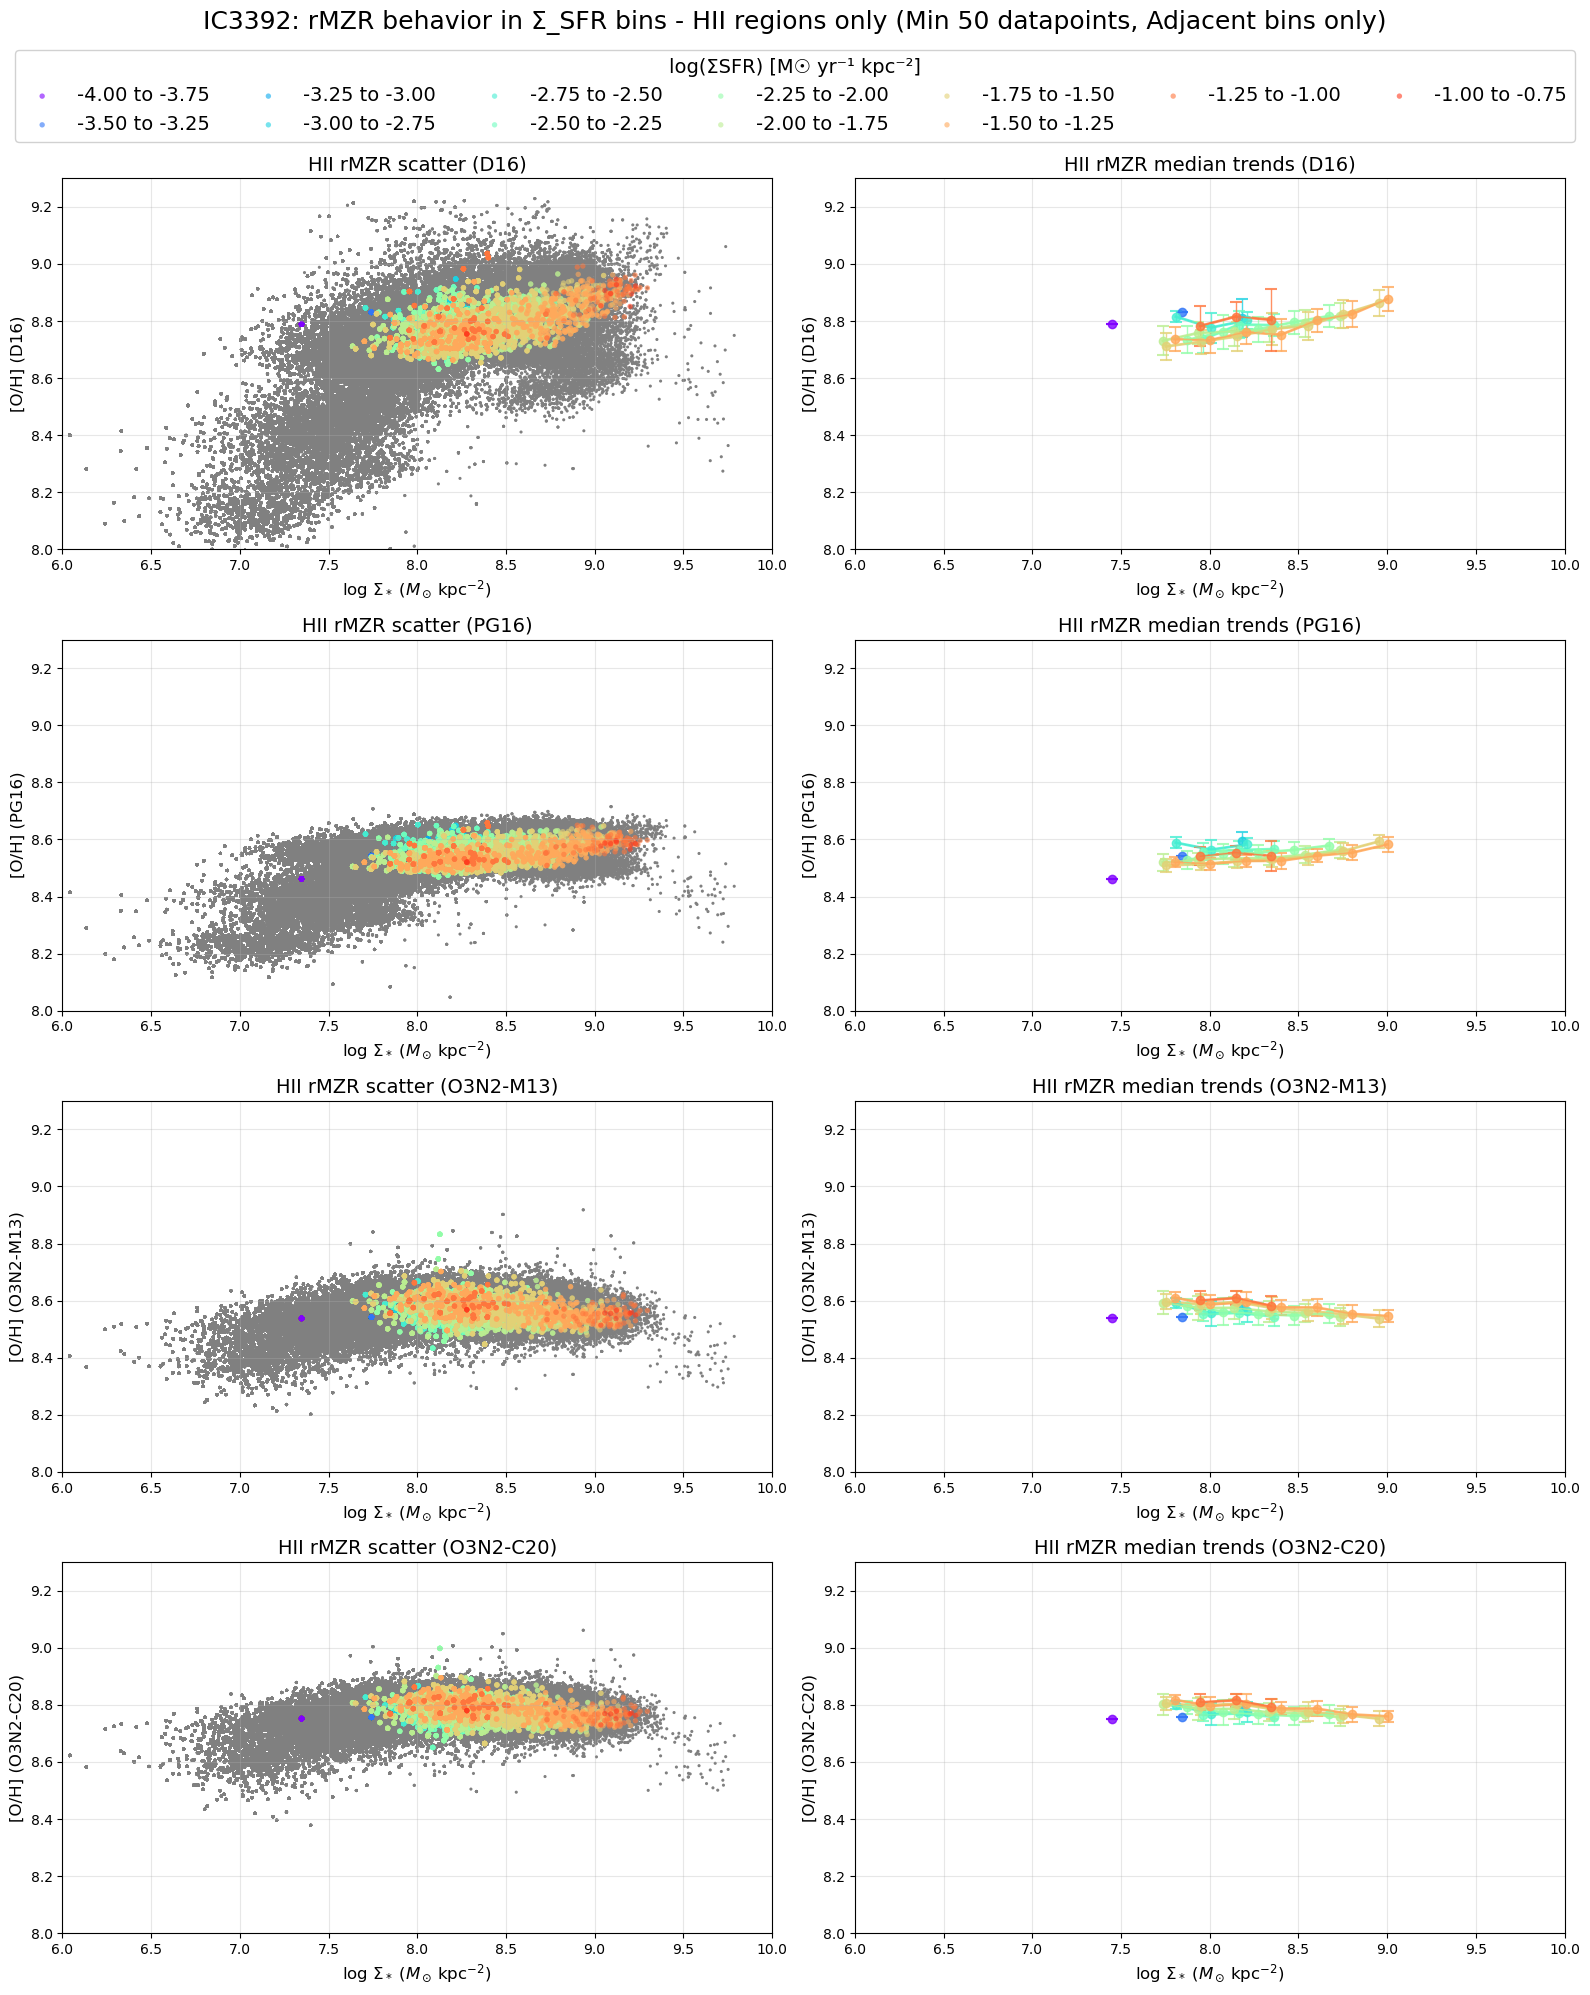


Successfully created 4x2 subplot figure for IC3392

Processing galaxy: NGC4064
Total HII pixels with all calibrations: 6820

Processing D16 calibration for HII regions:
  HII D16 range: 8.543 to 9.206
  Total valid bins: 11

Processing PG16 calibration for HII regions:
  HII PG16 range: 8.391 to 8.657
  Total valid bins: 11

Processing O3N2-M13 calibration for HII regions:
  HII O3N2-M13 range: 8.297 to 8.698
  Total valid bins: 11

Processing O3N2-C20 calibration for HII regions:
  HII O3N2-C20 range: 8.500 to 8.892
  Total valid bins: 11
  Total valid bins: 11

Processing PG16 calibration for HII regions:
  HII PG16 range: 8.391 to 8.657
  Total valid bins: 11

Processing O3N2-M13 calibration for HII regions:
  HII O3N2-M13 range: 8.297 to 8.698
  Total valid bins: 11

Processing O3N2-C20 calibration for HII regions:
  HII O3N2-C20 range: 8.500 to 8.892
  Total valid bins: 11


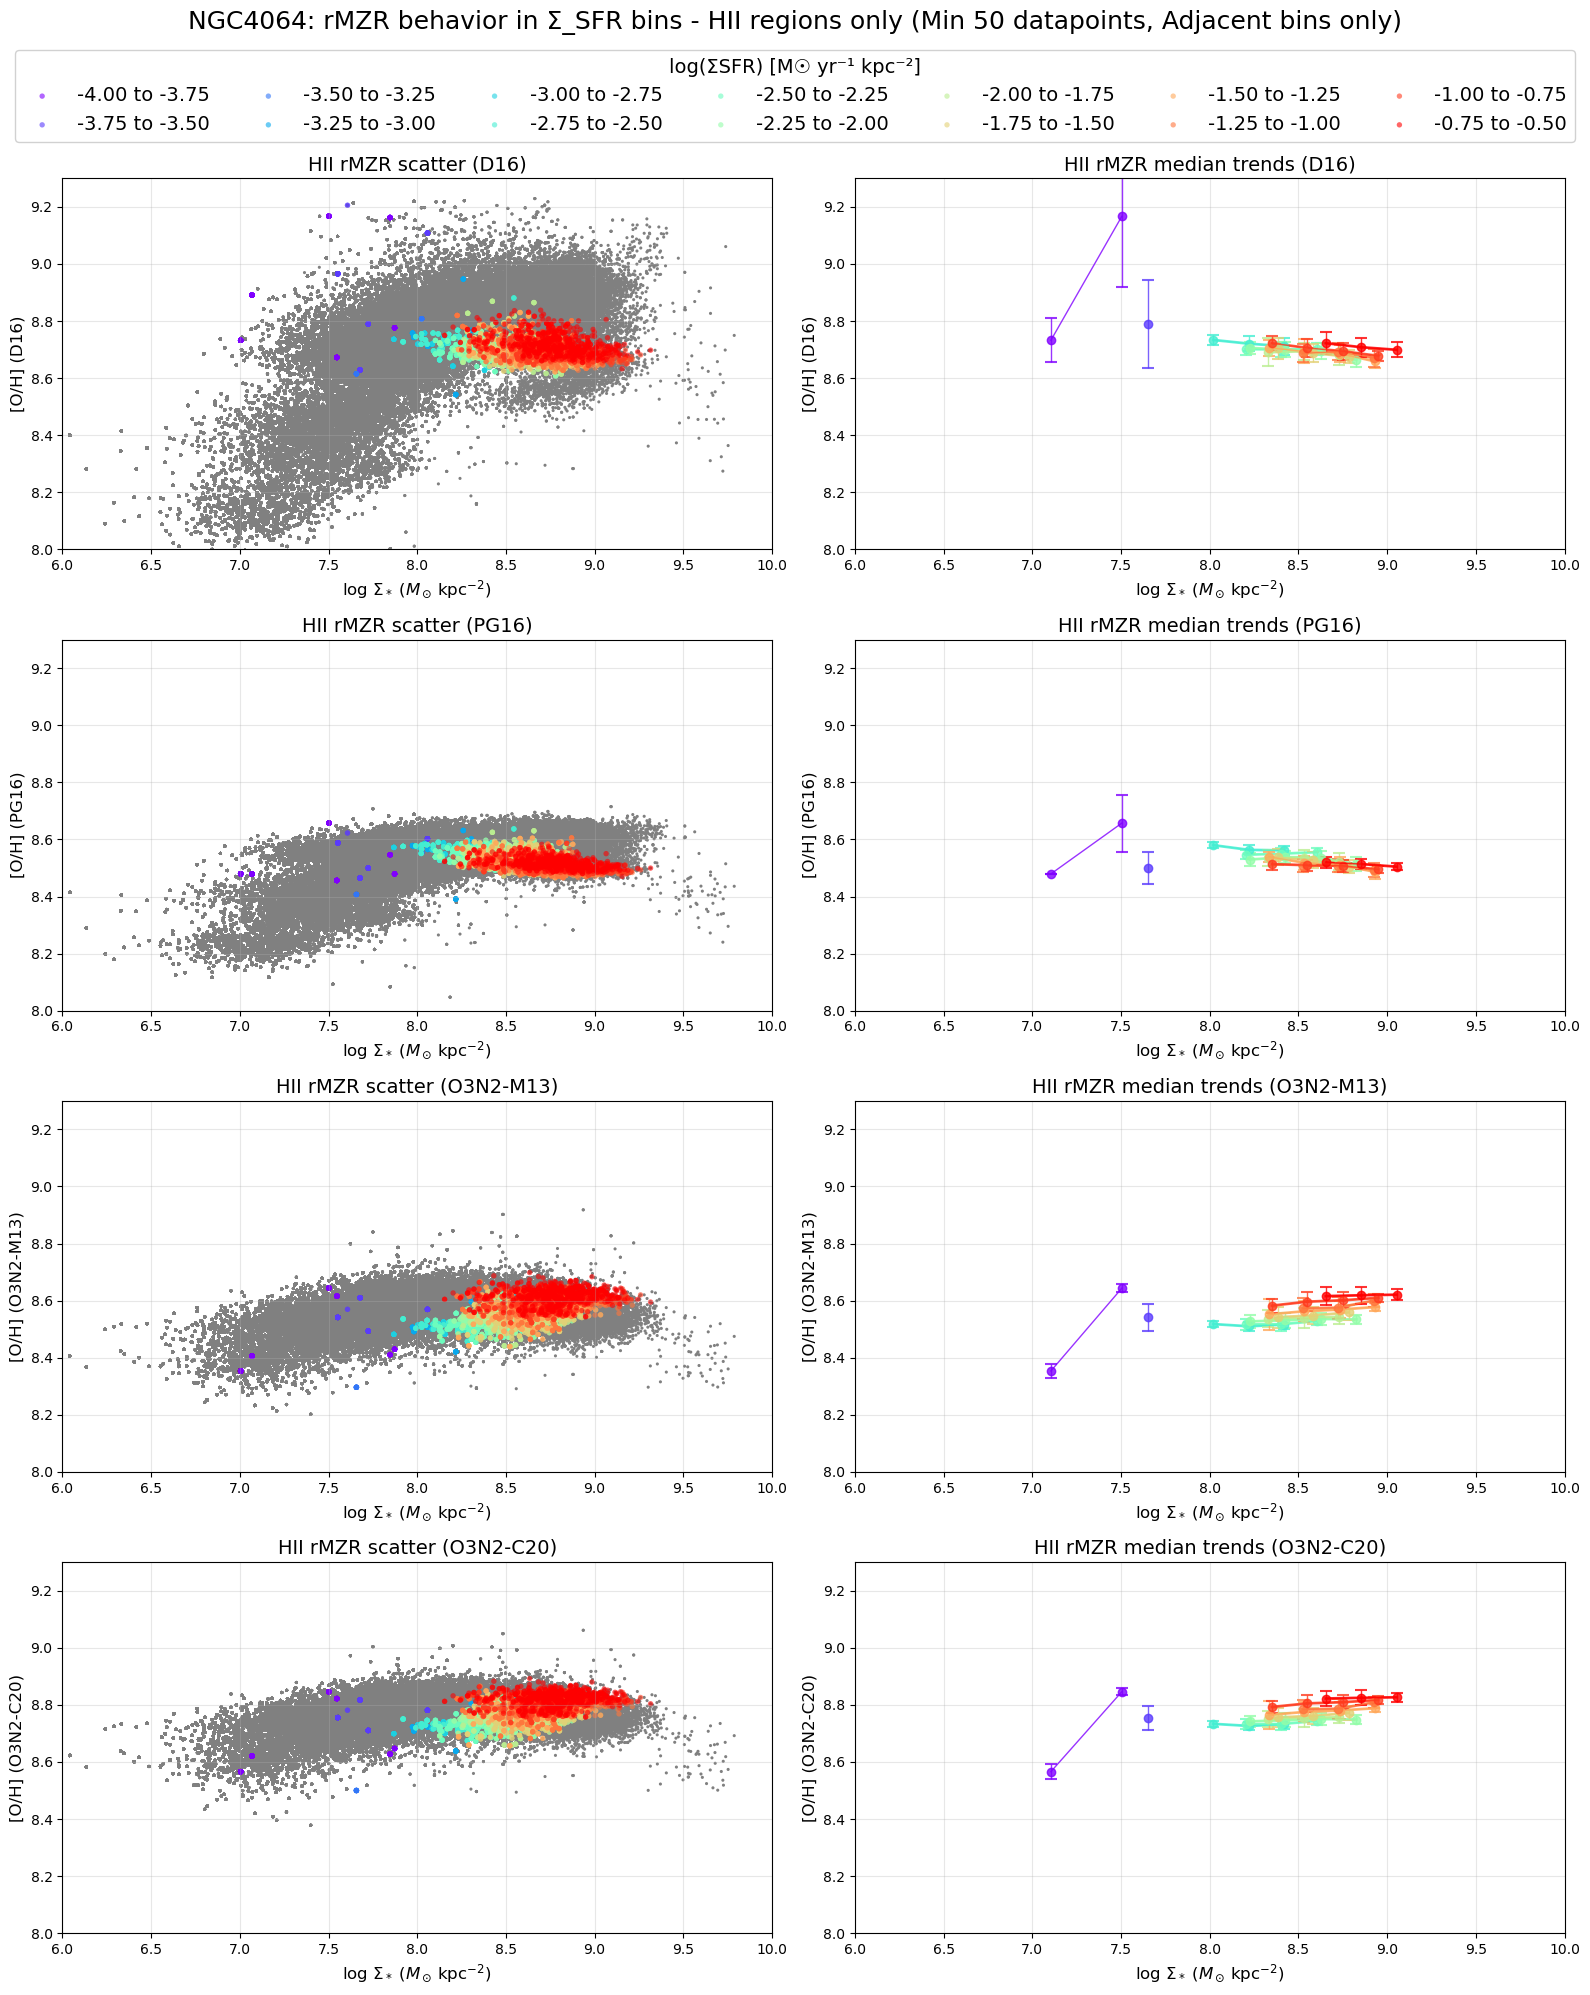


Successfully created 4x2 subplot figure for NGC4064

Processing galaxy: NGC4192
Total HII pixels with all calibrations: 145934

Processing D16 calibration for HII regions:
  HII D16 range: 8.523 to 9.222
  Total valid bins: 14

Processing PG16 calibration for HII regions:
  HII PG16 range: 8.414 to 8.715
  Total valid bins: 14

Processing O3N2-M13 calibration for HII regions:
  HII O3N2-M13 range: 8.398 to 8.918
  Total valid bins: 14

Processing O3N2-C20 calibration for HII regions:
  HII O3N2-C20 range: 8.614 to 9.061
Total HII pixels with all calibrations: 145934

Processing D16 calibration for HII regions:
  HII D16 range: 8.523 to 9.222
  Total valid bins: 14

Processing PG16 calibration for HII regions:
  HII PG16 range: 8.414 to 8.715
  Total valid bins: 14

Processing O3N2-M13 calibration for HII regions:
  HII O3N2-M13 range: 8.398 to 8.918
  Total valid bins: 14

Processing O3N2-C20 calibration for HII regions:
  HII O3N2-C20 range: 8.614 to 9.061
  Total valid bins: 14
  To

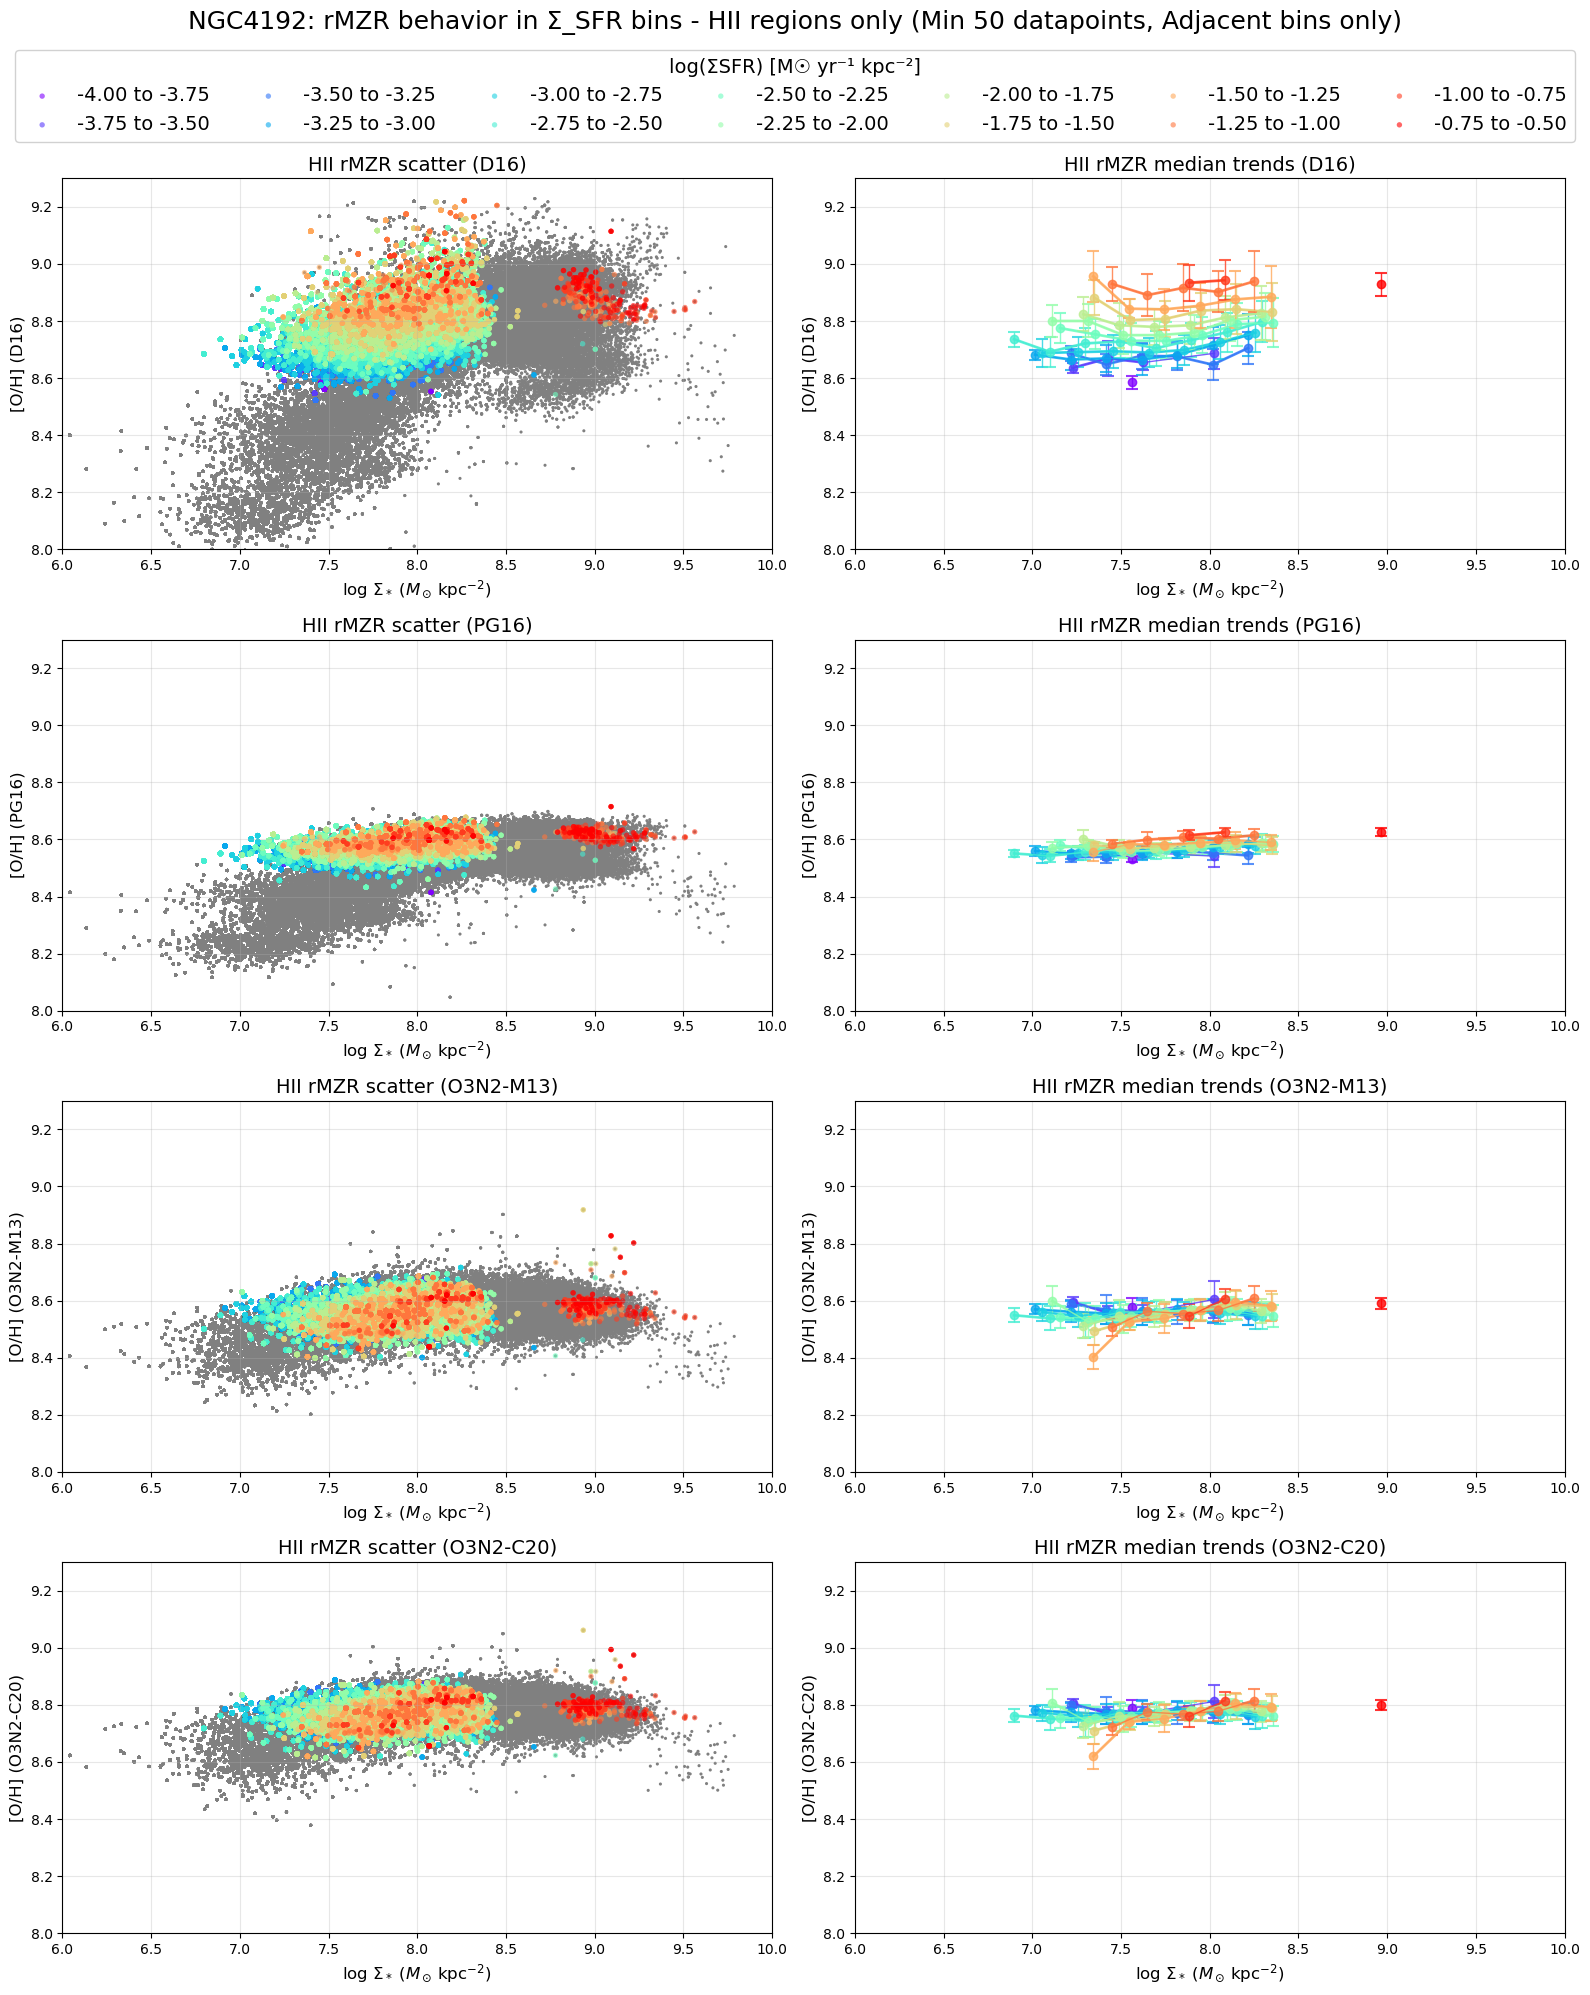


Successfully created 4x2 subplot figure for NGC4192

Processing galaxy: NGC4293
Total HII pixels with all calibrations: 3854

Processing D16 calibration for HII regions:
  HII D16 range: 7.941 to 9.218
  Total valid bins: 8

Processing PG16 calibration for HII regions:
  HII PG16 range: 7.796 to 8.707
  Total valid bins: 8

Processing O3N2-M13 calibration for HII regions:
  HII O3N2-M13 range: 8.294 to 8.841
  Total valid bins: 8

Processing O3N2-C20 calibration for HII regions:
  HII O3N2-C20 range: 8.496 to 9.004
  Total valid bins: 8
  Total valid bins: 8

Processing PG16 calibration for HII regions:
  HII PG16 range: 7.796 to 8.707
  Total valid bins: 8

Processing O3N2-M13 calibration for HII regions:
  HII O3N2-M13 range: 8.294 to 8.841
  Total valid bins: 8

Processing O3N2-C20 calibration for HII regions:
  HII O3N2-C20 range: 8.496 to 9.004
  Total valid bins: 8


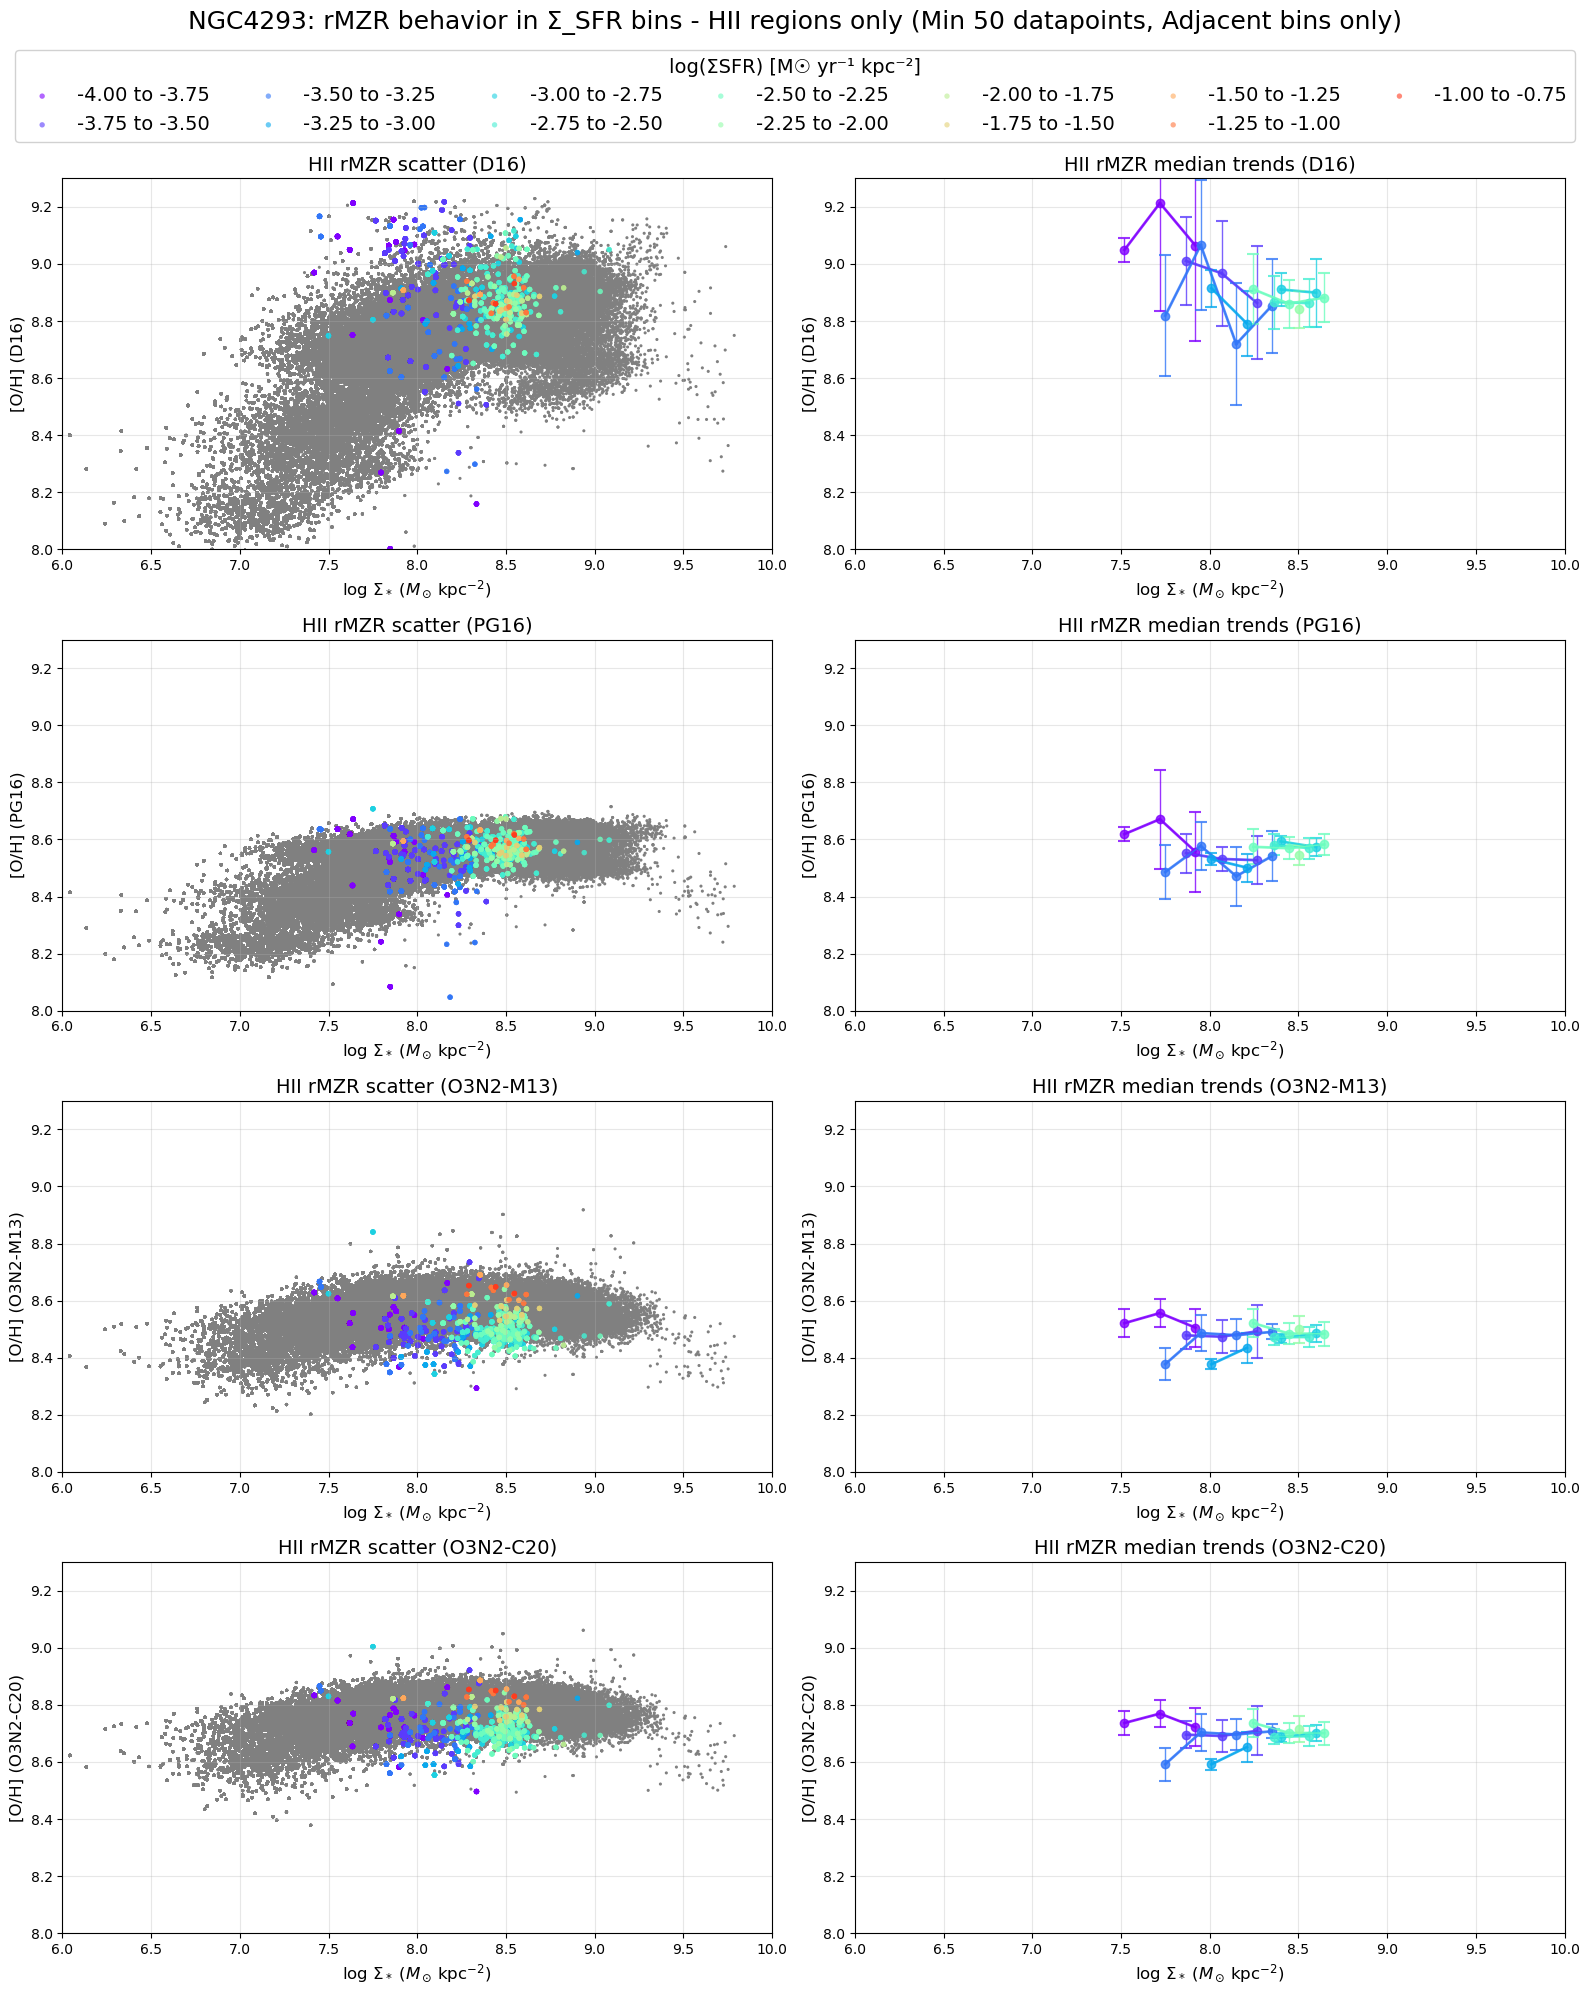


Successfully created 4x2 subplot figure for NGC4293

Processing galaxy: NGC4298
Total HII pixels with all calibrations: 156350

Processing D16 calibration for HII regions:
  HII D16 range: 8.479 to 9.030
  Total valid bins: 12

Processing PG16 calibration for HII regions:
  HII PG16 range: 8.402 to 8.647
  Total valid bins: 12

Processing O3N2-M13 calibration for HII regions:
  HII O3N2-M13 range: 8.394 to 8.845
Total HII pixels with all calibrations: 156350

Processing D16 calibration for HII regions:
  HII D16 range: 8.479 to 9.030
  Total valid bins: 12

Processing PG16 calibration for HII regions:
  HII PG16 range: 8.402 to 8.647
  Total valid bins: 12

Processing O3N2-M13 calibration for HII regions:
  HII O3N2-M13 range: 8.394 to 8.845
  Total valid bins: 12

Processing O3N2-C20 calibration for HII regions:
  HII O3N2-C20 range: 8.610 to 9.007
  Total valid bins: 12
  Total valid bins: 12

Processing O3N2-C20 calibration for HII regions:
  HII O3N2-C20 range: 8.610 to 9.007
  To

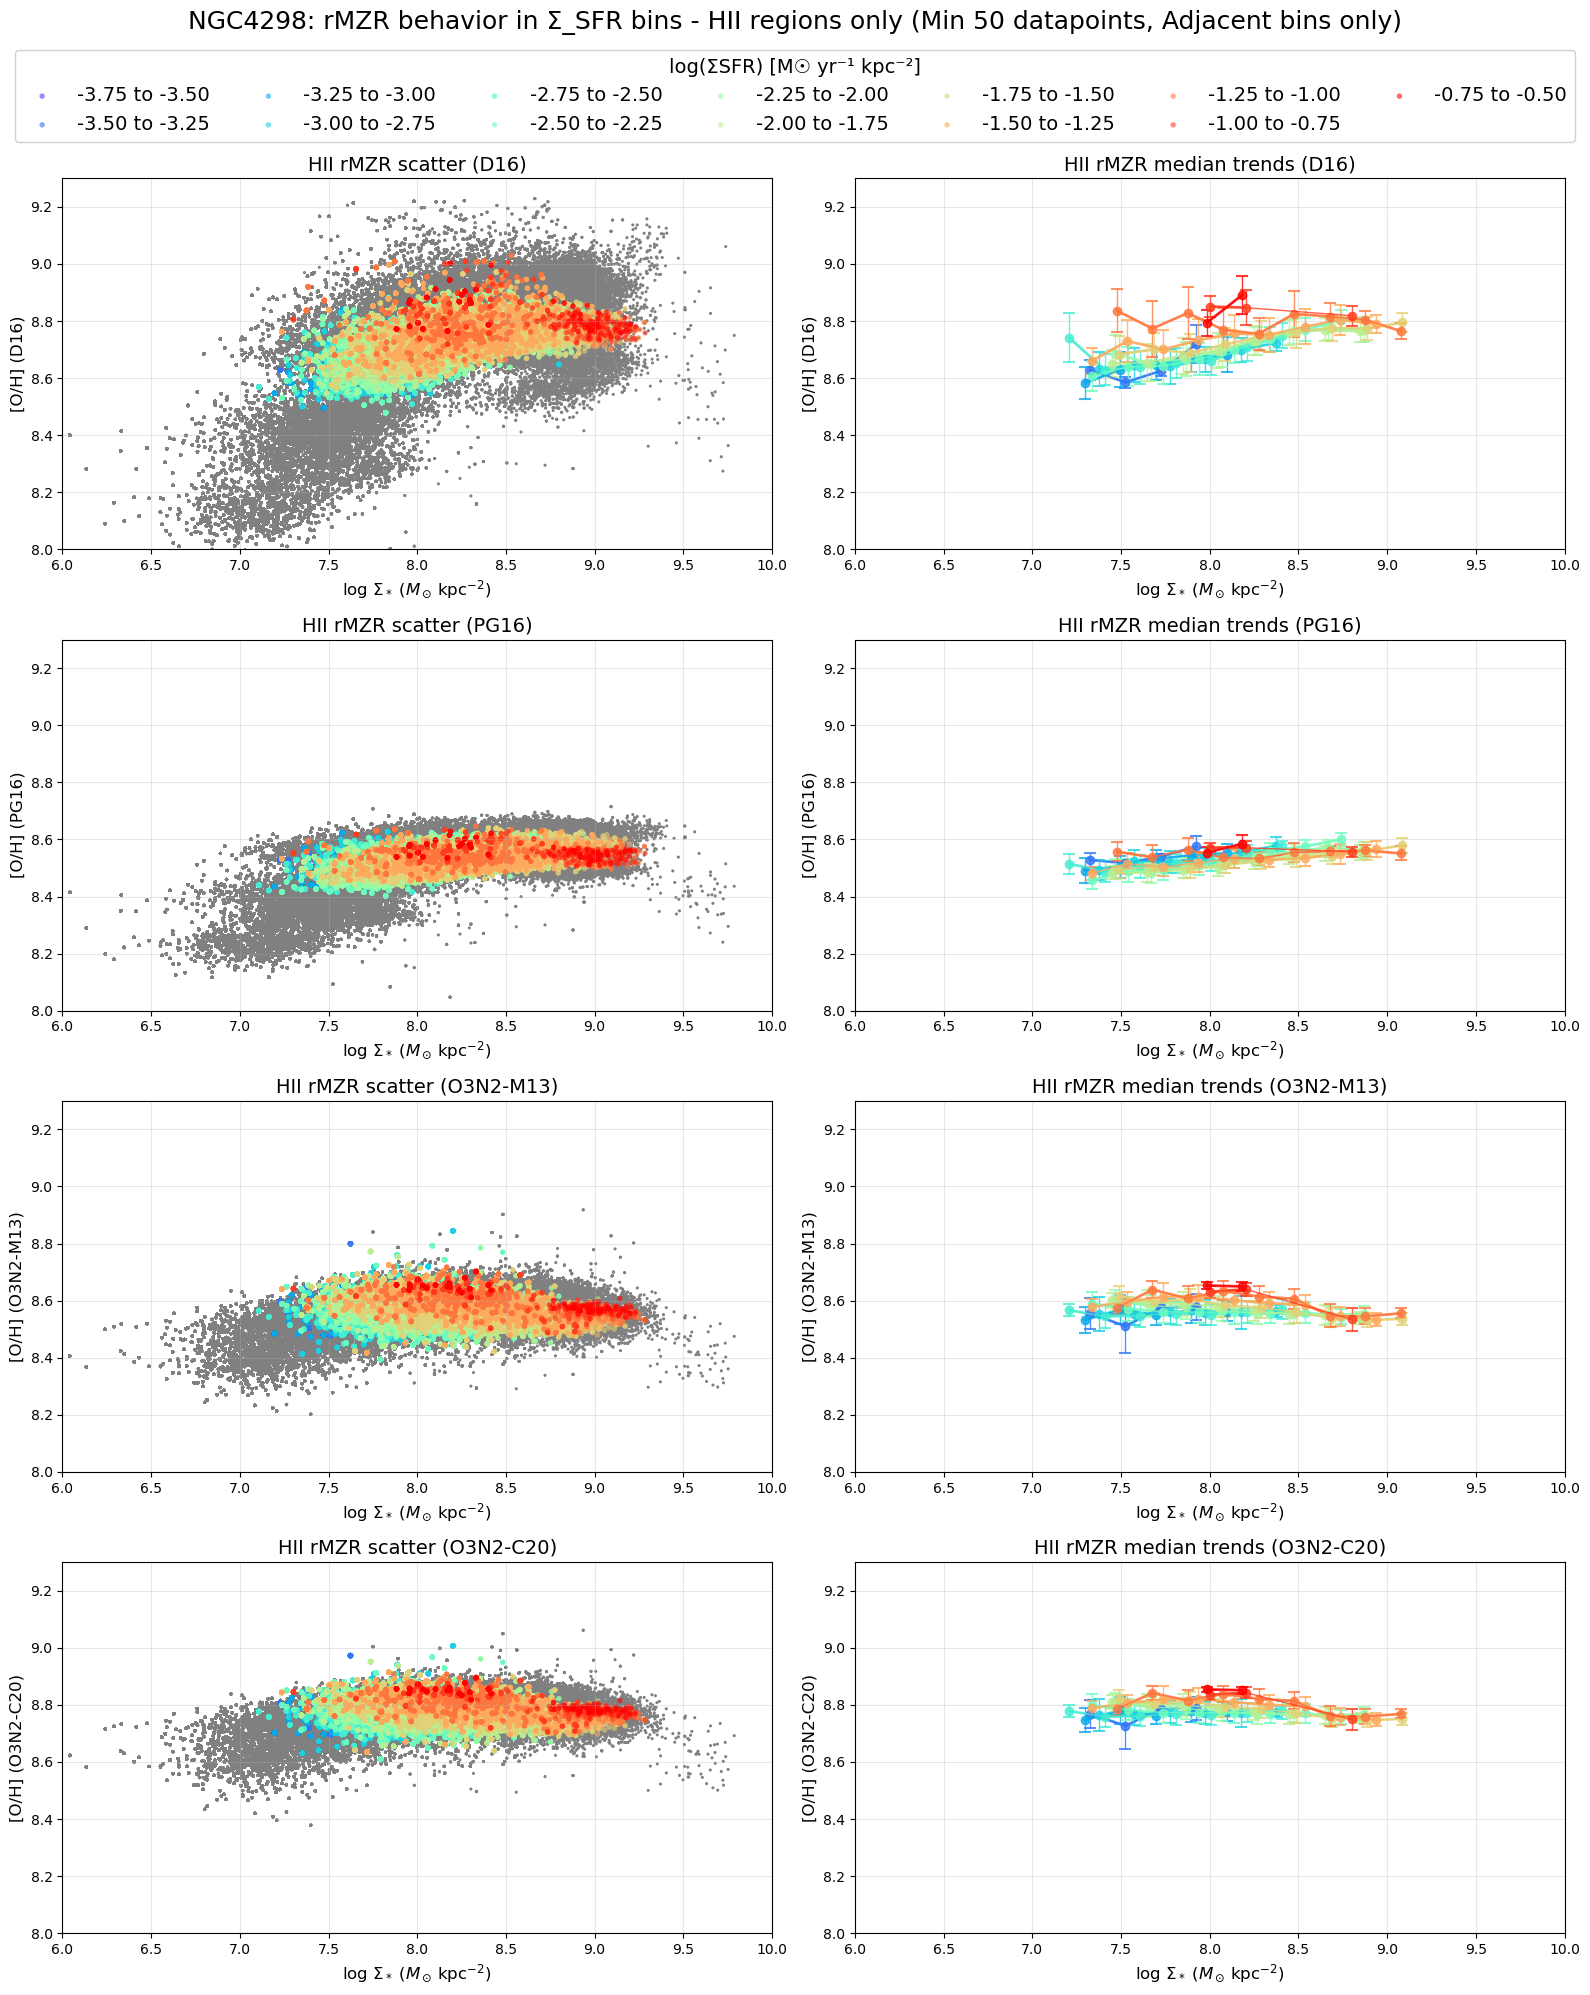


Successfully created 4x2 subplot figure for NGC4298

Processing galaxy: NGC4330
Total HII pixels with all calibrations: 42566

Processing D16 calibration for HII regions:
  HII D16 range: 8.171 to 8.887
  Total valid bins: 11

Processing PG16 calibration for HII regions:
  HII PG16 range: 8.228 to 8.581
  Total valid bins: 11

Processing O3N2-M13 calibration for HII regions:
  HII O3N2-M13 range: 8.300 to 8.700
  Total valid bins: 11

Processing O3N2-C20 calibration for HII regions:
  HII O3N2-C20 range: 8.503 to 8.893
  Total valid bins: 11
  Total valid bins: 11

Processing PG16 calibration for HII regions:
  HII PG16 range: 8.228 to 8.581
  Total valid bins: 11

Processing O3N2-M13 calibration for HII regions:
  HII O3N2-M13 range: 8.300 to 8.700
  Total valid bins: 11

Processing O3N2-C20 calibration for HII regions:
  HII O3N2-C20 range: 8.503 to 8.893
  Total valid bins: 11


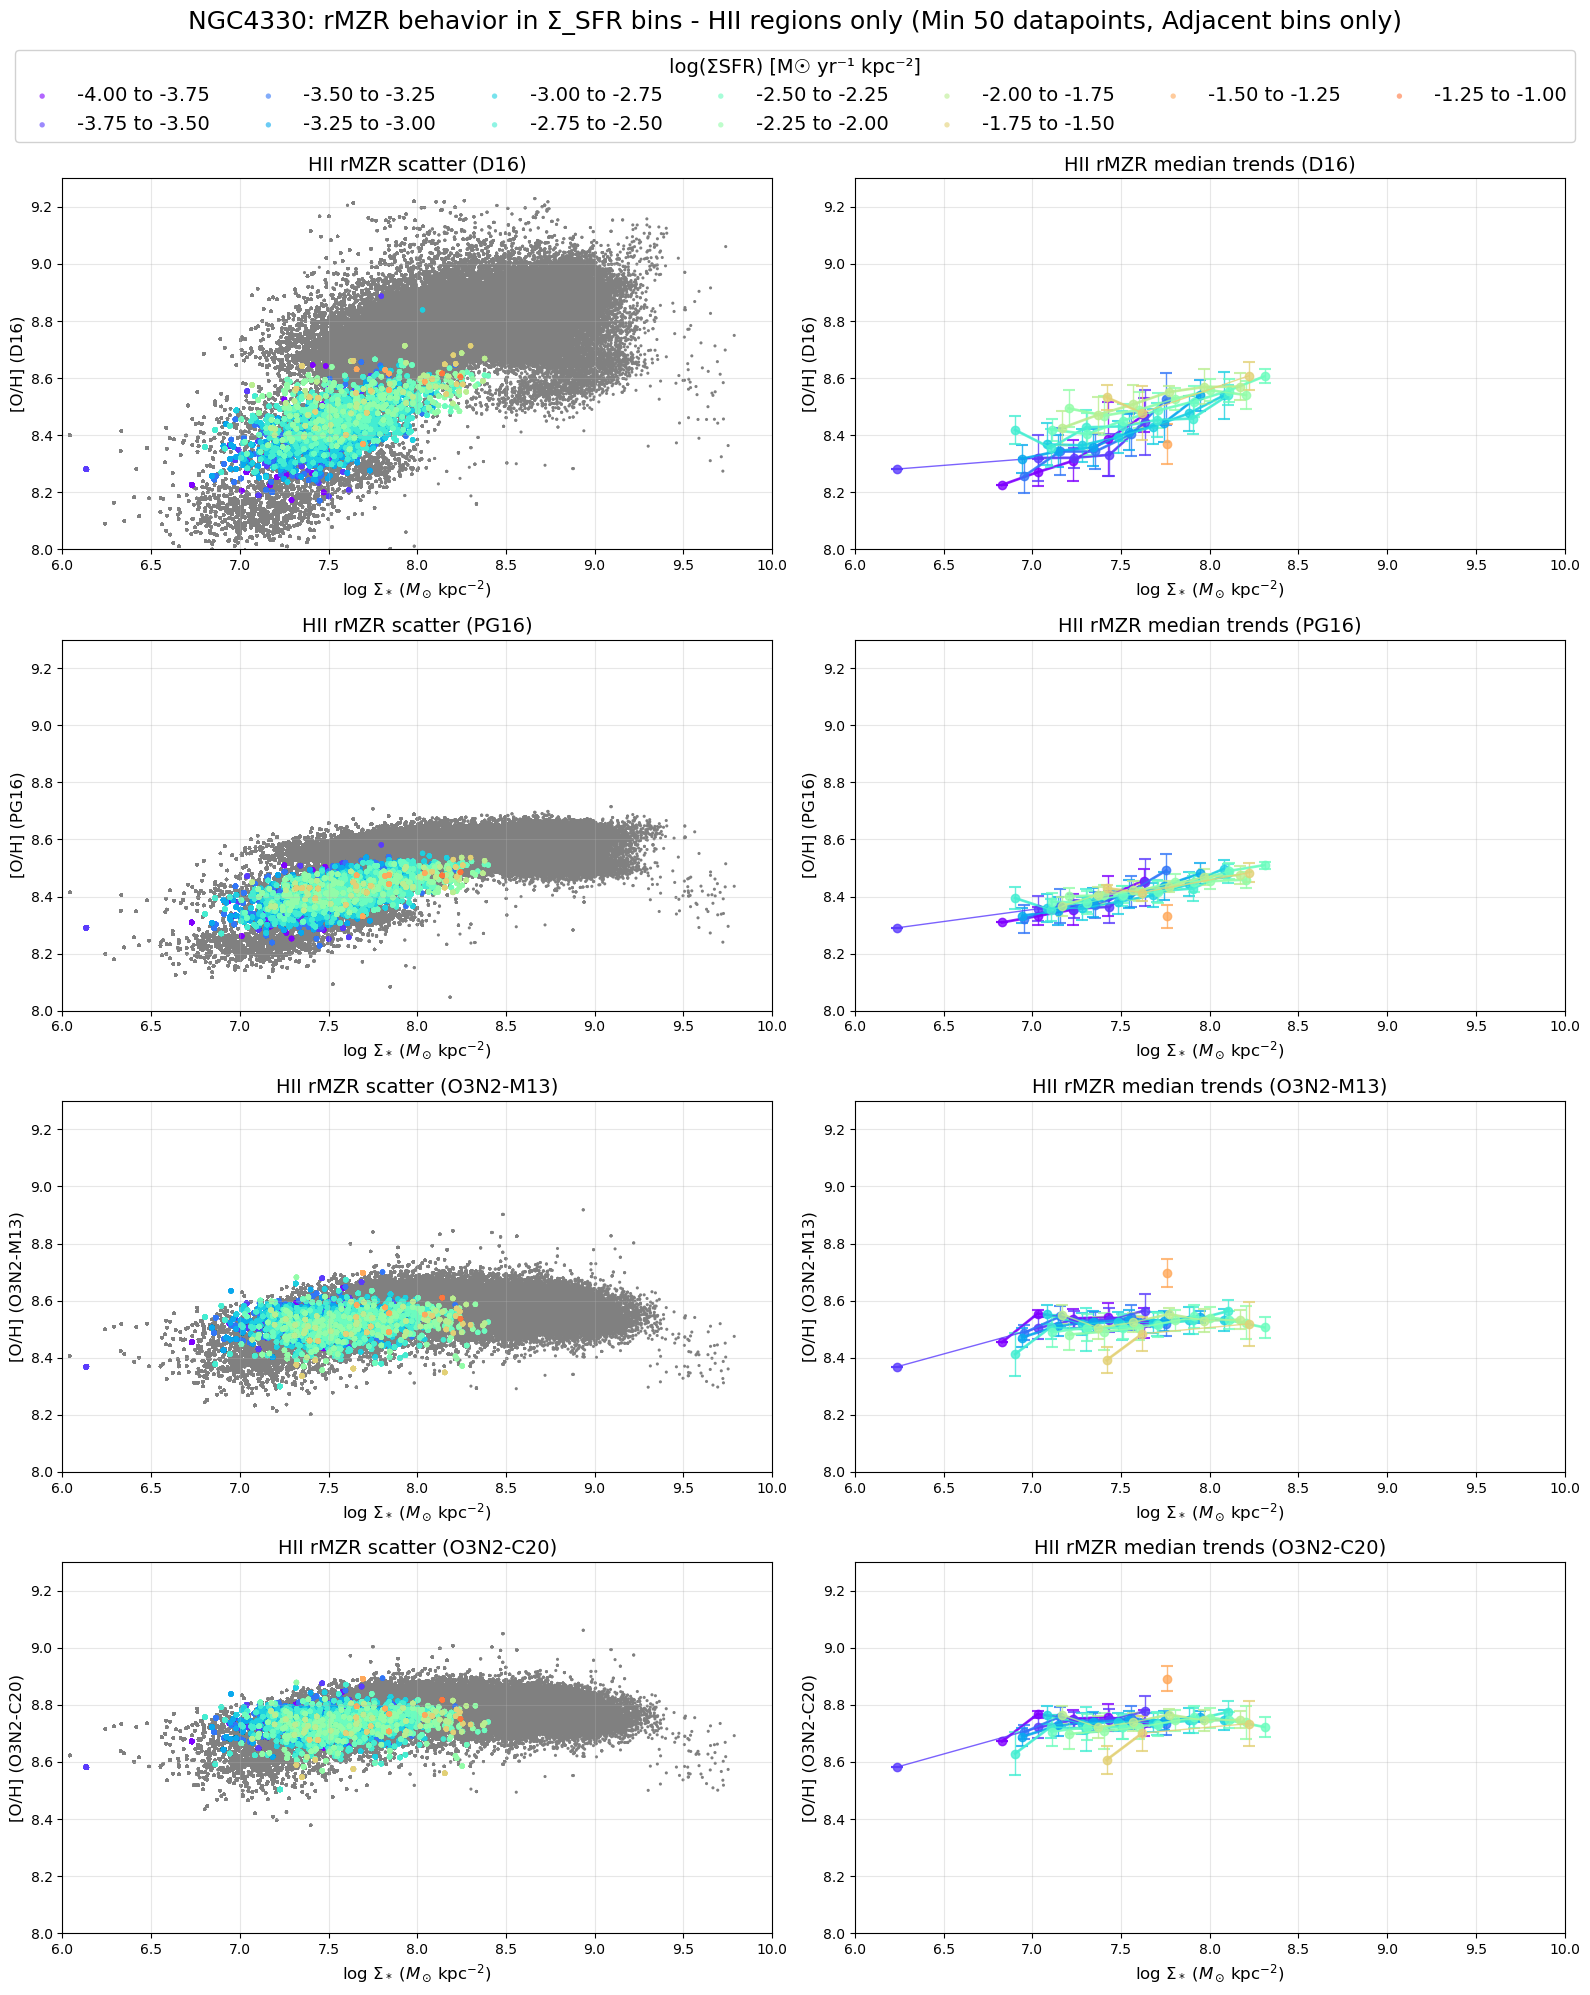


Successfully created 4x2 subplot figure for NGC4330

Skipping NGC4383 (excluded from analysis)

Processing galaxy: NGC4396
Total HII pixels with all calibrations: 81728

Processing D16 calibration for HII regions:
  HII D16 range: 7.906 to 9.099
  Total valid bins: 11

Processing PG16 calibration for HII regions:
  HII PG16 range: 8.093 to 8.599
Total HII pixels with all calibrations: 81728

Processing D16 calibration for HII regions:
  HII D16 range: 7.906 to 9.099
  Total valid bins: 11

Processing PG16 calibration for HII regions:
  HII PG16 range: 8.093 to 8.599
  Total valid bins: 11

Processing O3N2-M13 calibration for HII regions:
  HII O3N2-M13 range: 8.202 to 8.687
  Total valid bins: 11

Processing O3N2-C20 calibration for HII regions:
  HII O3N2-C20 range: 8.378 to 8.882
  Total valid bins: 11
  Total valid bins: 11

Processing O3N2-M13 calibration for HII regions:
  HII O3N2-M13 range: 8.202 to 8.687
  Total valid bins: 11

Processing O3N2-C20 calibration for HII regions:


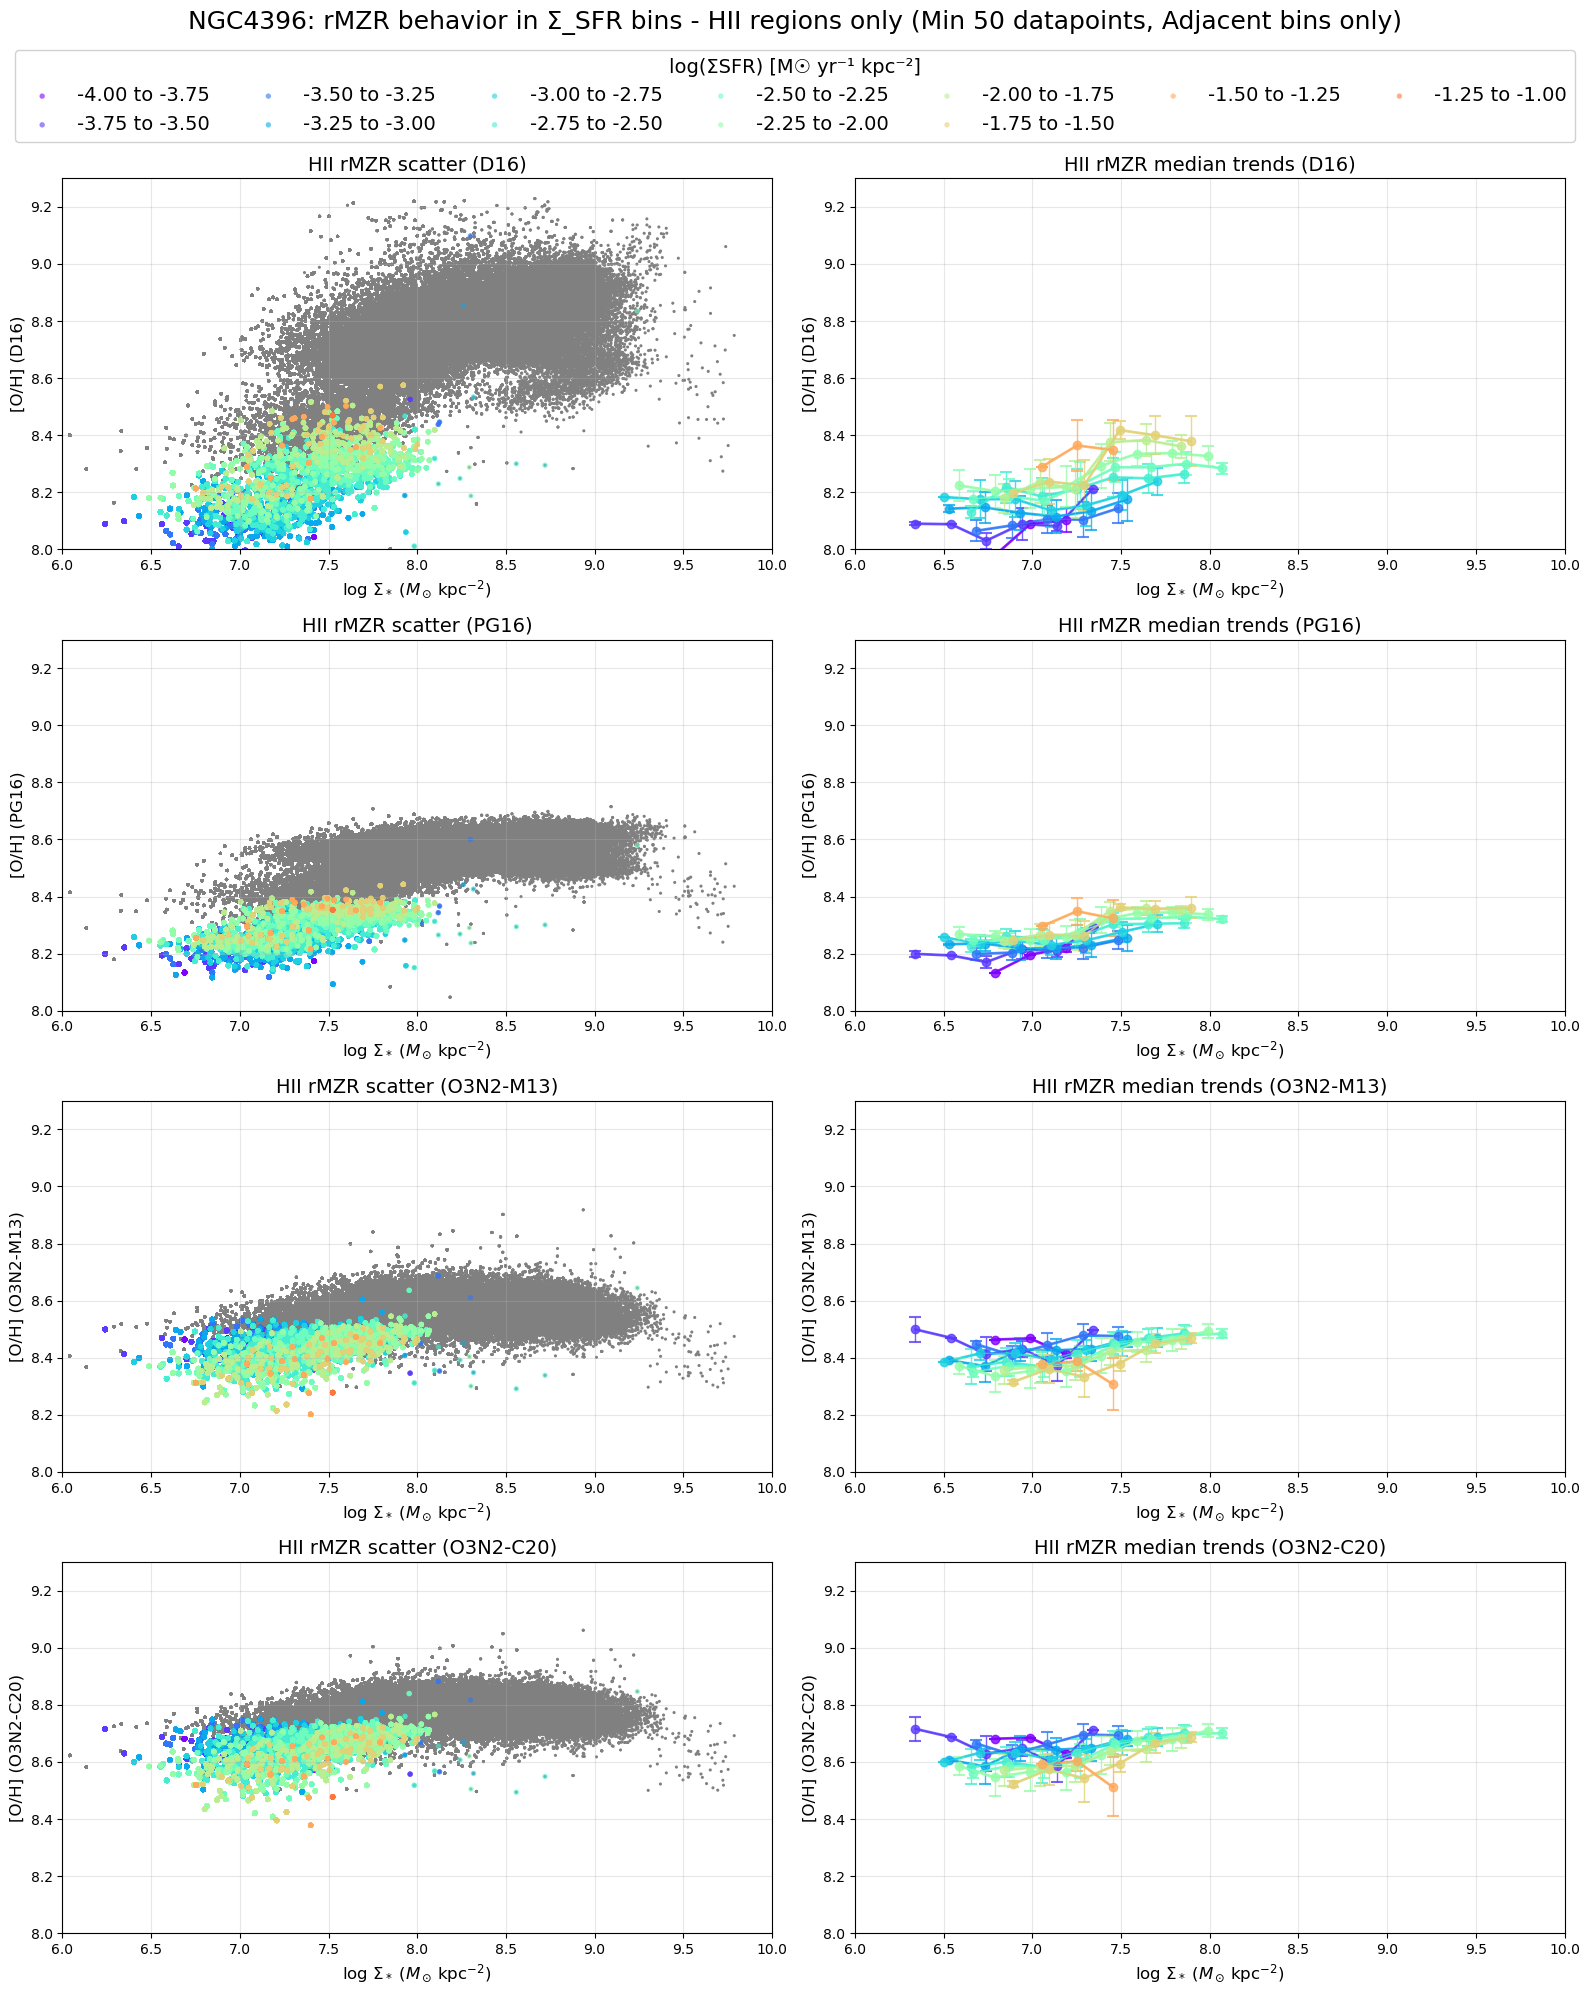


Successfully created 4x2 subplot figure for NGC4396

Processing galaxy: NGC4419
Total HII pixels with all calibrations: 6886

Processing D16 calibration for HII regions:
  HII D16 range: 8.432 to 9.130
  Total valid bins: 10

Processing PG16 calibration for HII regions:
  HII PG16 range: 8.340 to 8.675
  Total valid bins: 10

Processing O3N2-M13 calibration for HII regions:
  HII O3N2-M13 range: 8.300 to 8.902
  Total valid bins: 10

Processing O3N2-C20 calibration for HII regions:
  HII O3N2-C20 range: 8.505 to 9.049
Total HII pixels with all calibrations: 6886

Processing D16 calibration for HII regions:
  HII D16 range: 8.432 to 9.130
  Total valid bins: 10

Processing PG16 calibration for HII regions:
  HII PG16 range: 8.340 to 8.675
  Total valid bins: 10

Processing O3N2-M13 calibration for HII regions:
  HII O3N2-M13 range: 8.300 to 8.902
  Total valid bins: 10

Processing O3N2-C20 calibration for HII regions:
  HII O3N2-C20 range: 8.505 to 9.049
  Total valid bins: 10
  Total 

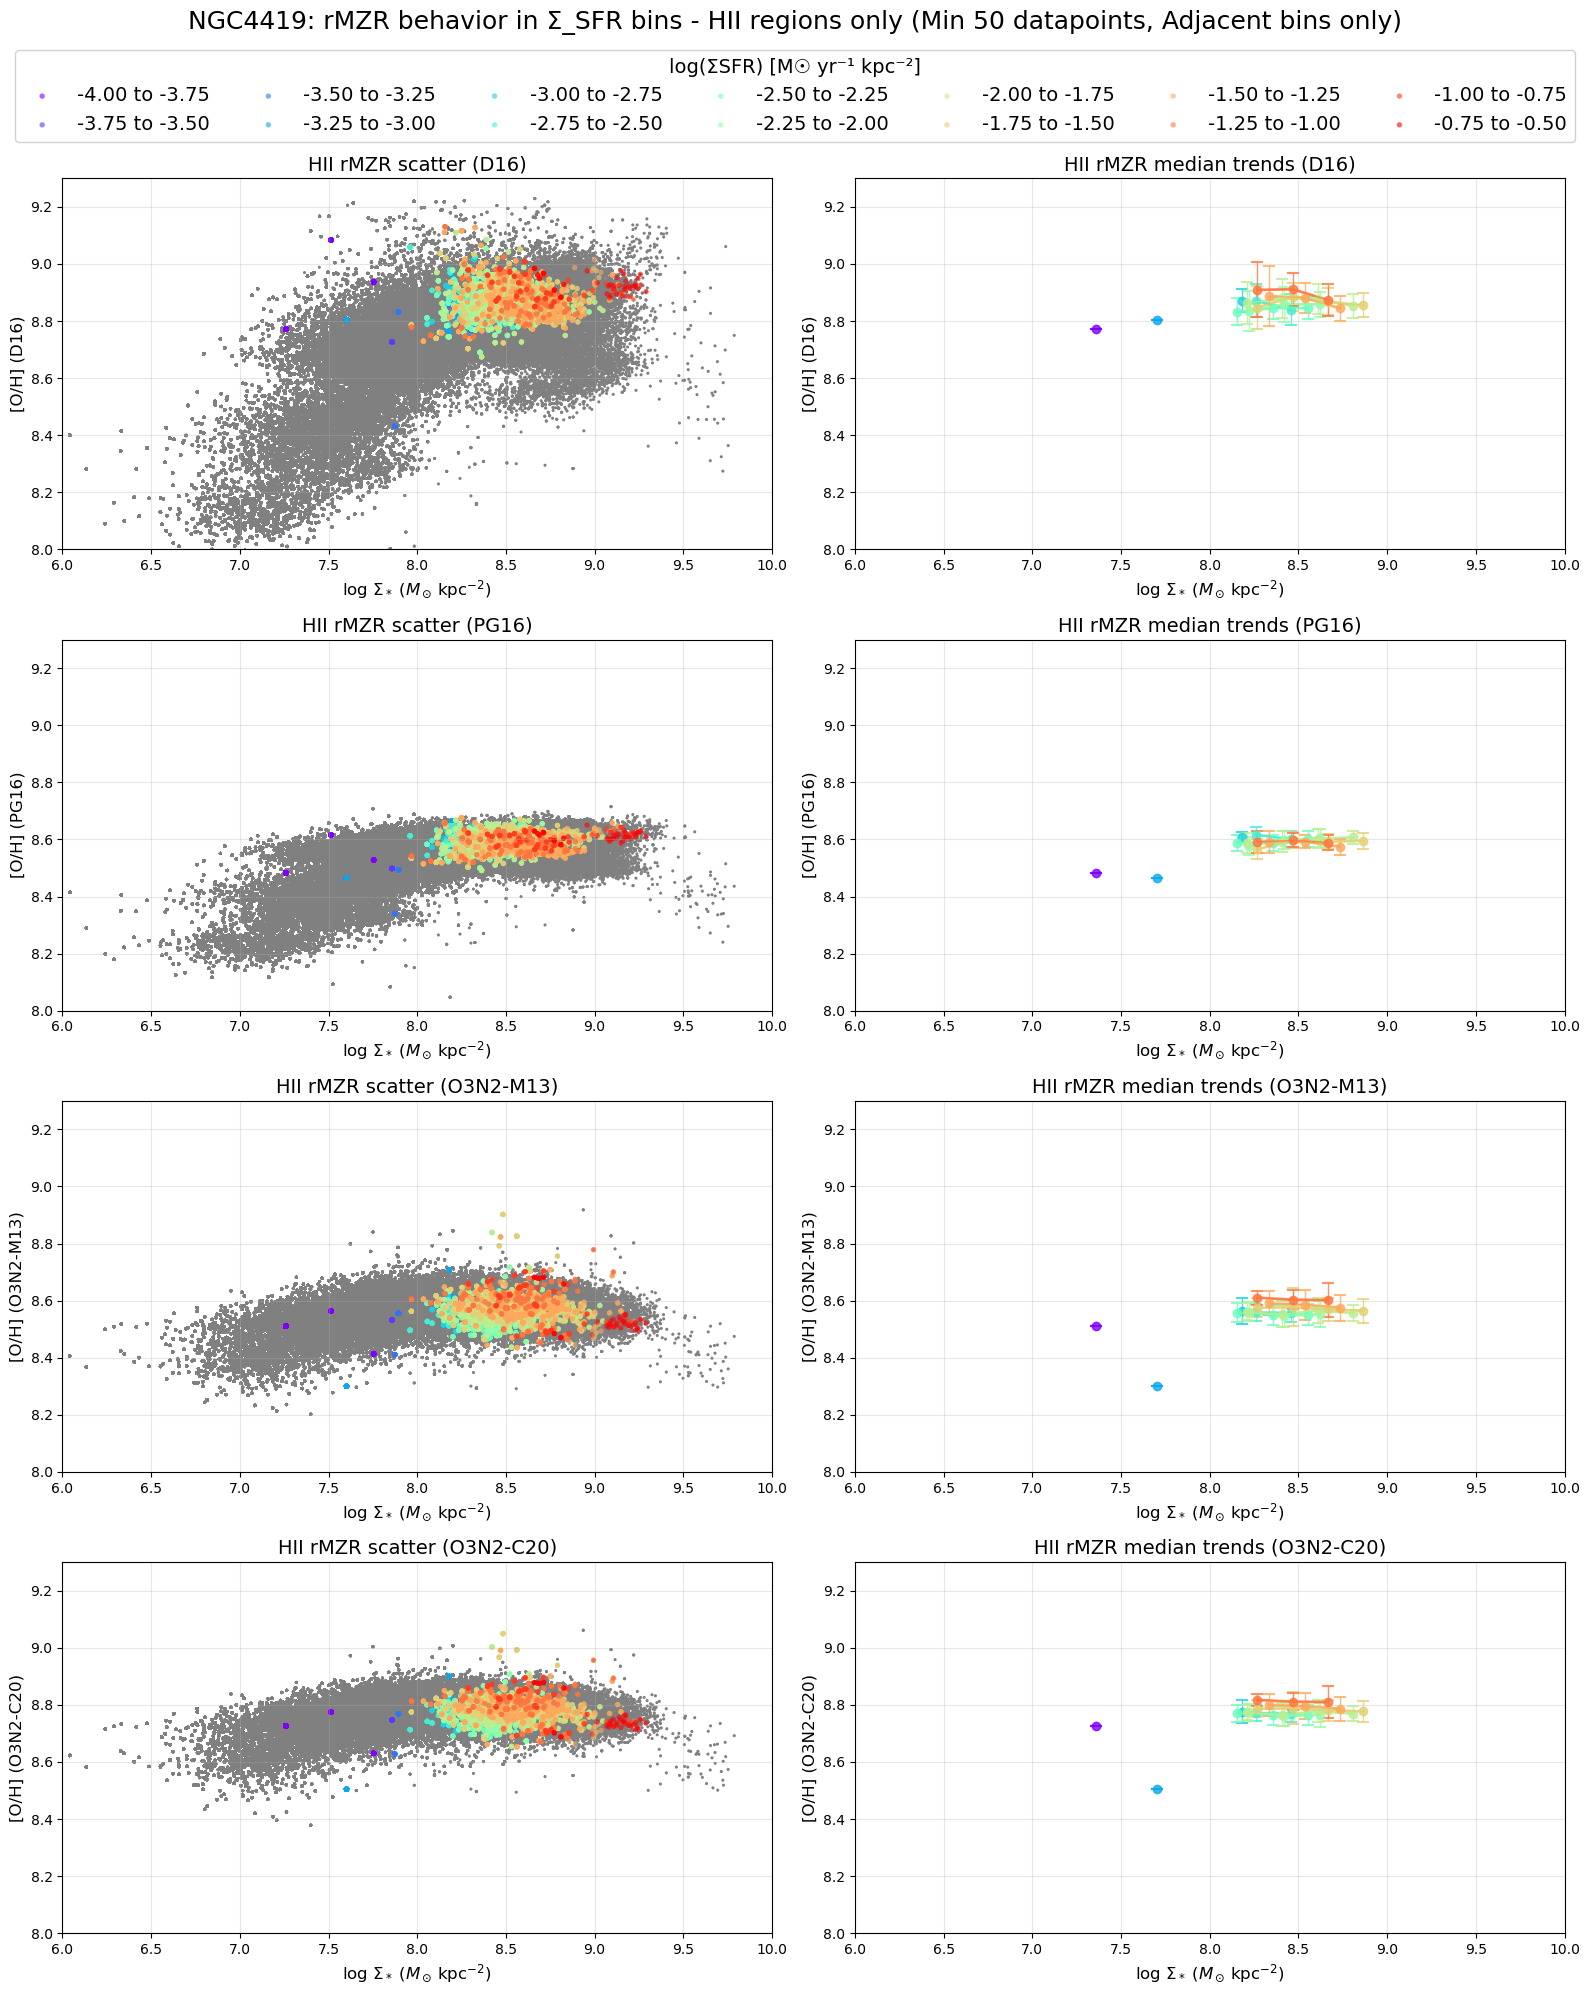


Successfully created 4x2 subplot figure for NGC4419

Processing galaxy: NGC4457
Total HII pixels with all calibrations: 6000

Processing D16 calibration for HII regions:
  HII D16 range: 8.283 to 9.096
Total HII pixels with all calibrations: 6000

Processing D16 calibration for HII regions:
  HII D16 range: 8.283 to 9.096
  Total valid bins: 8

Processing PG16 calibration for HII regions:
  HII PG16 range: 8.283 to 8.680
  Total valid bins: 8

Processing O3N2-M13 calibration for HII regions:
  HII O3N2-M13 range: 8.342 to 8.783
  Total valid bins: 8

Processing O3N2-C20 calibration for HII regions:
  HII O3N2-C20 range: 8.552 to 8.959
  Total valid bins: 8
  Total valid bins: 8

Processing PG16 calibration for HII regions:
  HII PG16 range: 8.283 to 8.680
  Total valid bins: 8

Processing O3N2-M13 calibration for HII regions:
  HII O3N2-M13 range: 8.342 to 8.783
  Total valid bins: 8

Processing O3N2-C20 calibration for HII regions:
  HII O3N2-C20 range: 8.552 to 8.959
  Total valid b

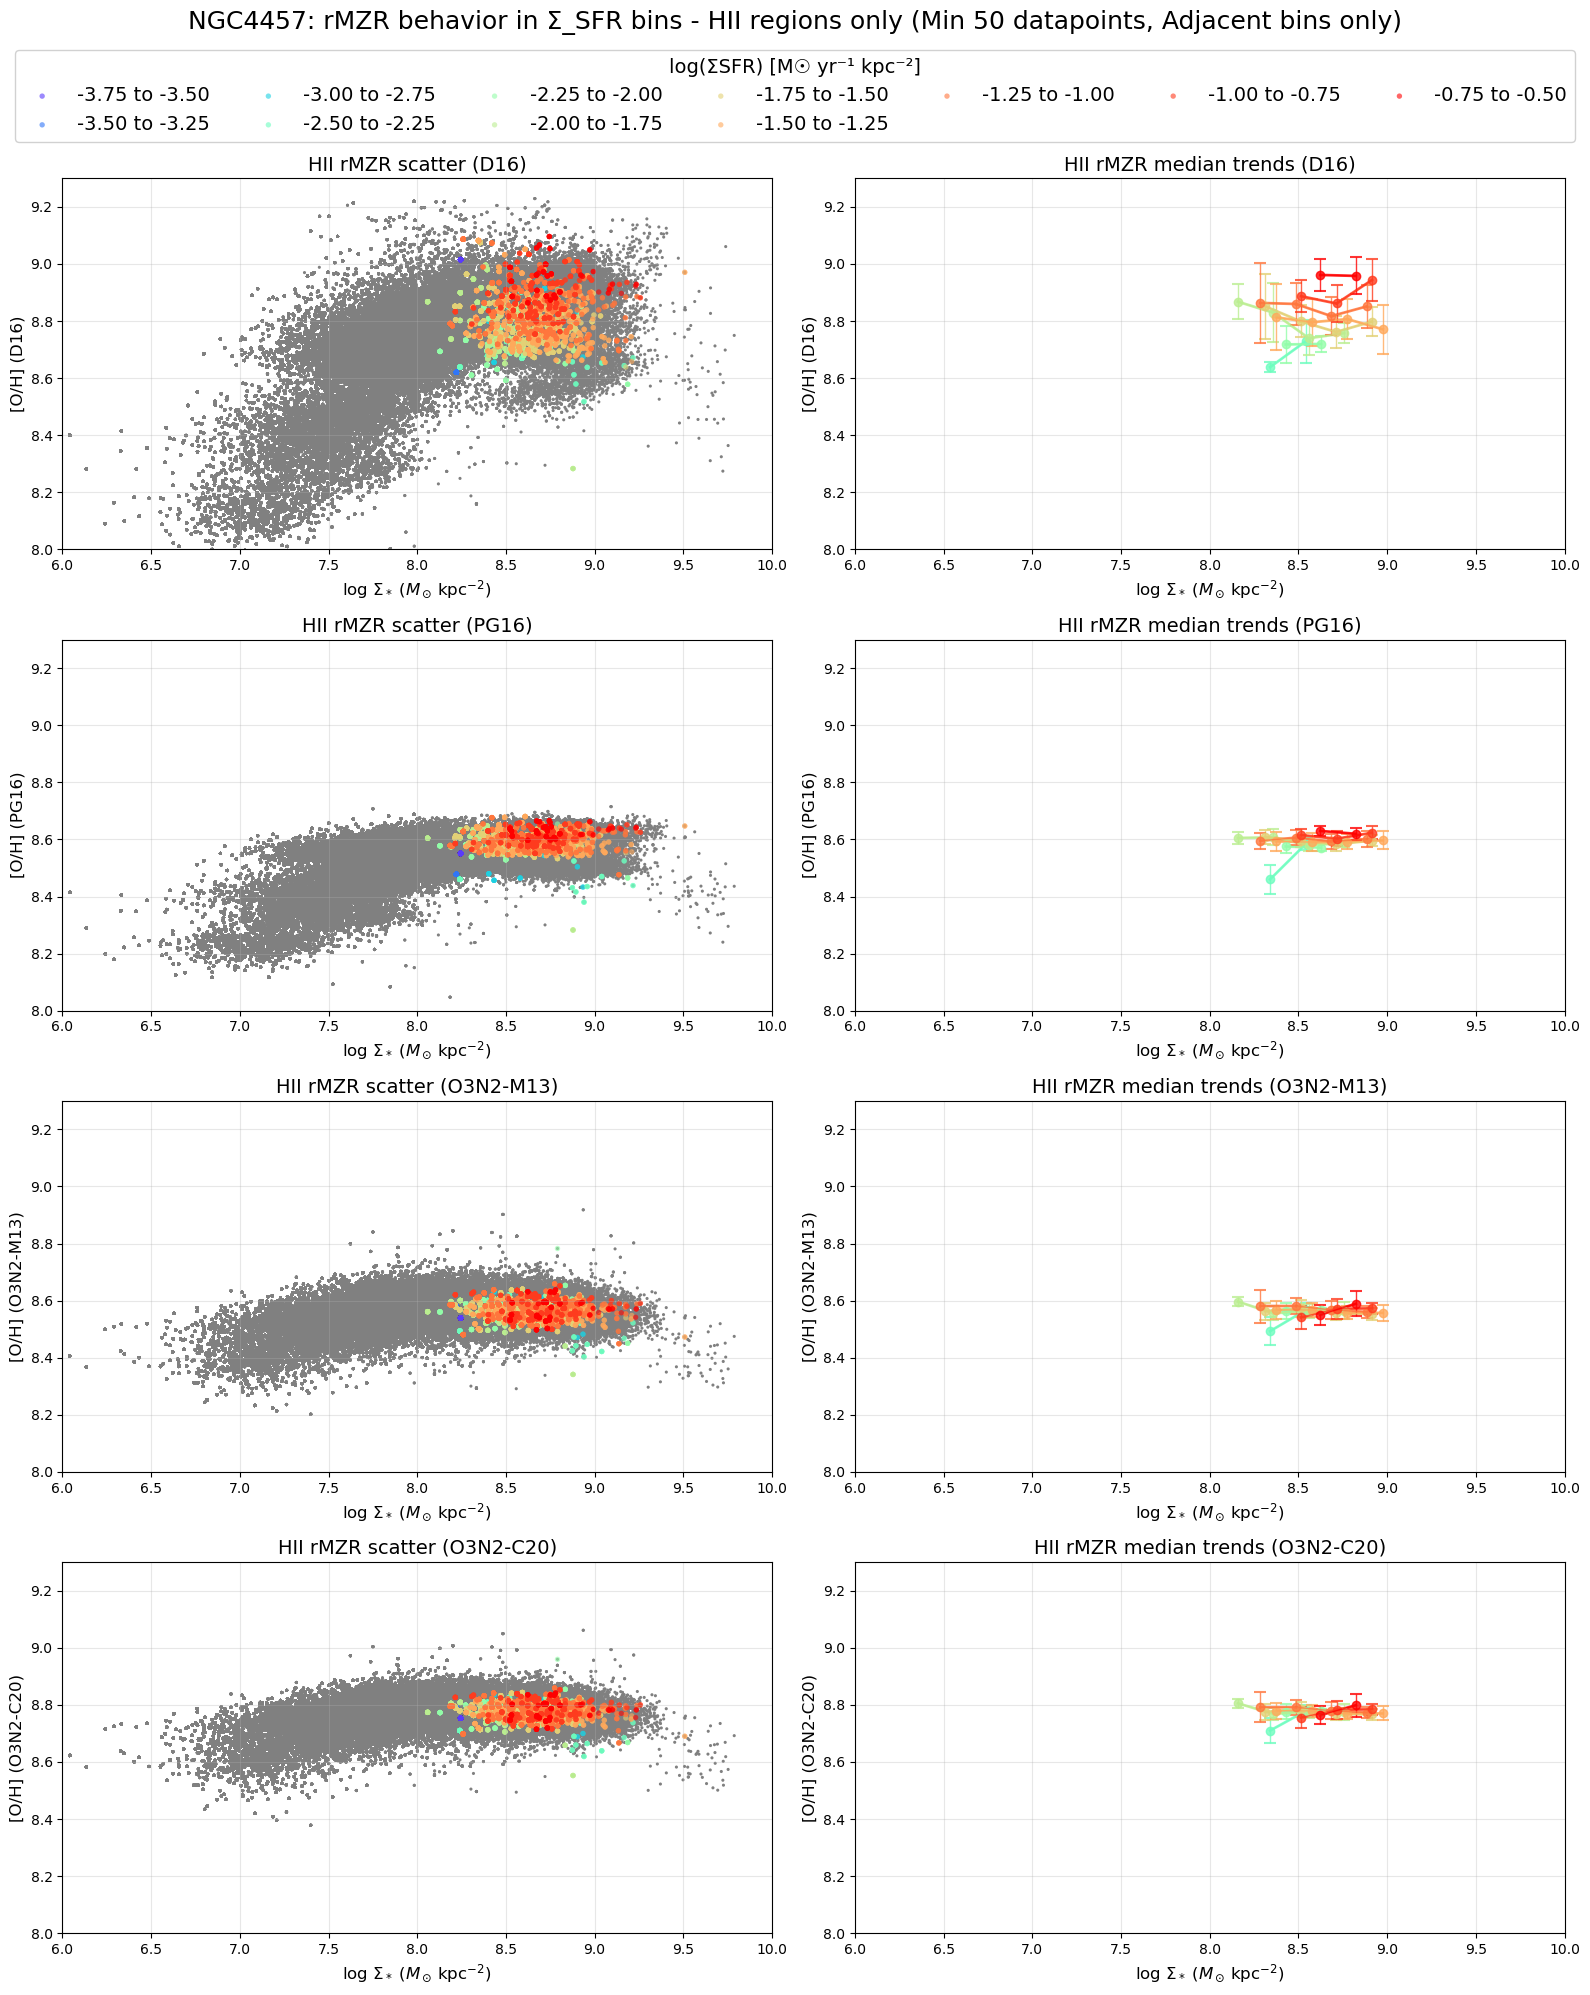


Successfully created 4x2 subplot figure for NGC4457

Processing galaxy: NGC4501
Total HII pixels with all calibrations: 260854

Processing D16 calibration for HII regions:
  HII D16 range: 8.494 to 9.229
Total HII pixels with all calibrations: 260854

Processing D16 calibration for HII regions:
  HII D16 range: 8.494 to 9.229
  Total valid bins: 14

Processing PG16 calibration for HII regions:
  HII PG16 range: 8.351 to 8.698
  Total valid bins: 14

Processing O3N2-M13 calibration for HII regions:
  HII O3N2-M13 range: 8.391 to 8.786
  Total valid bins: 14

Processing O3N2-C20 calibration for HII regions:
  HII O3N2-C20 range: 8.607 to 8.962
  Total valid bins: 14

Processing PG16 calibration for HII regions:
  HII PG16 range: 8.351 to 8.698
  Total valid bins: 14

Processing O3N2-M13 calibration for HII regions:
  HII O3N2-M13 range: 8.391 to 8.786
  Total valid bins: 14

Processing O3N2-C20 calibration for HII regions:
  HII O3N2-C20 range: 8.607 to 8.962
  Total valid bins: 14
  To

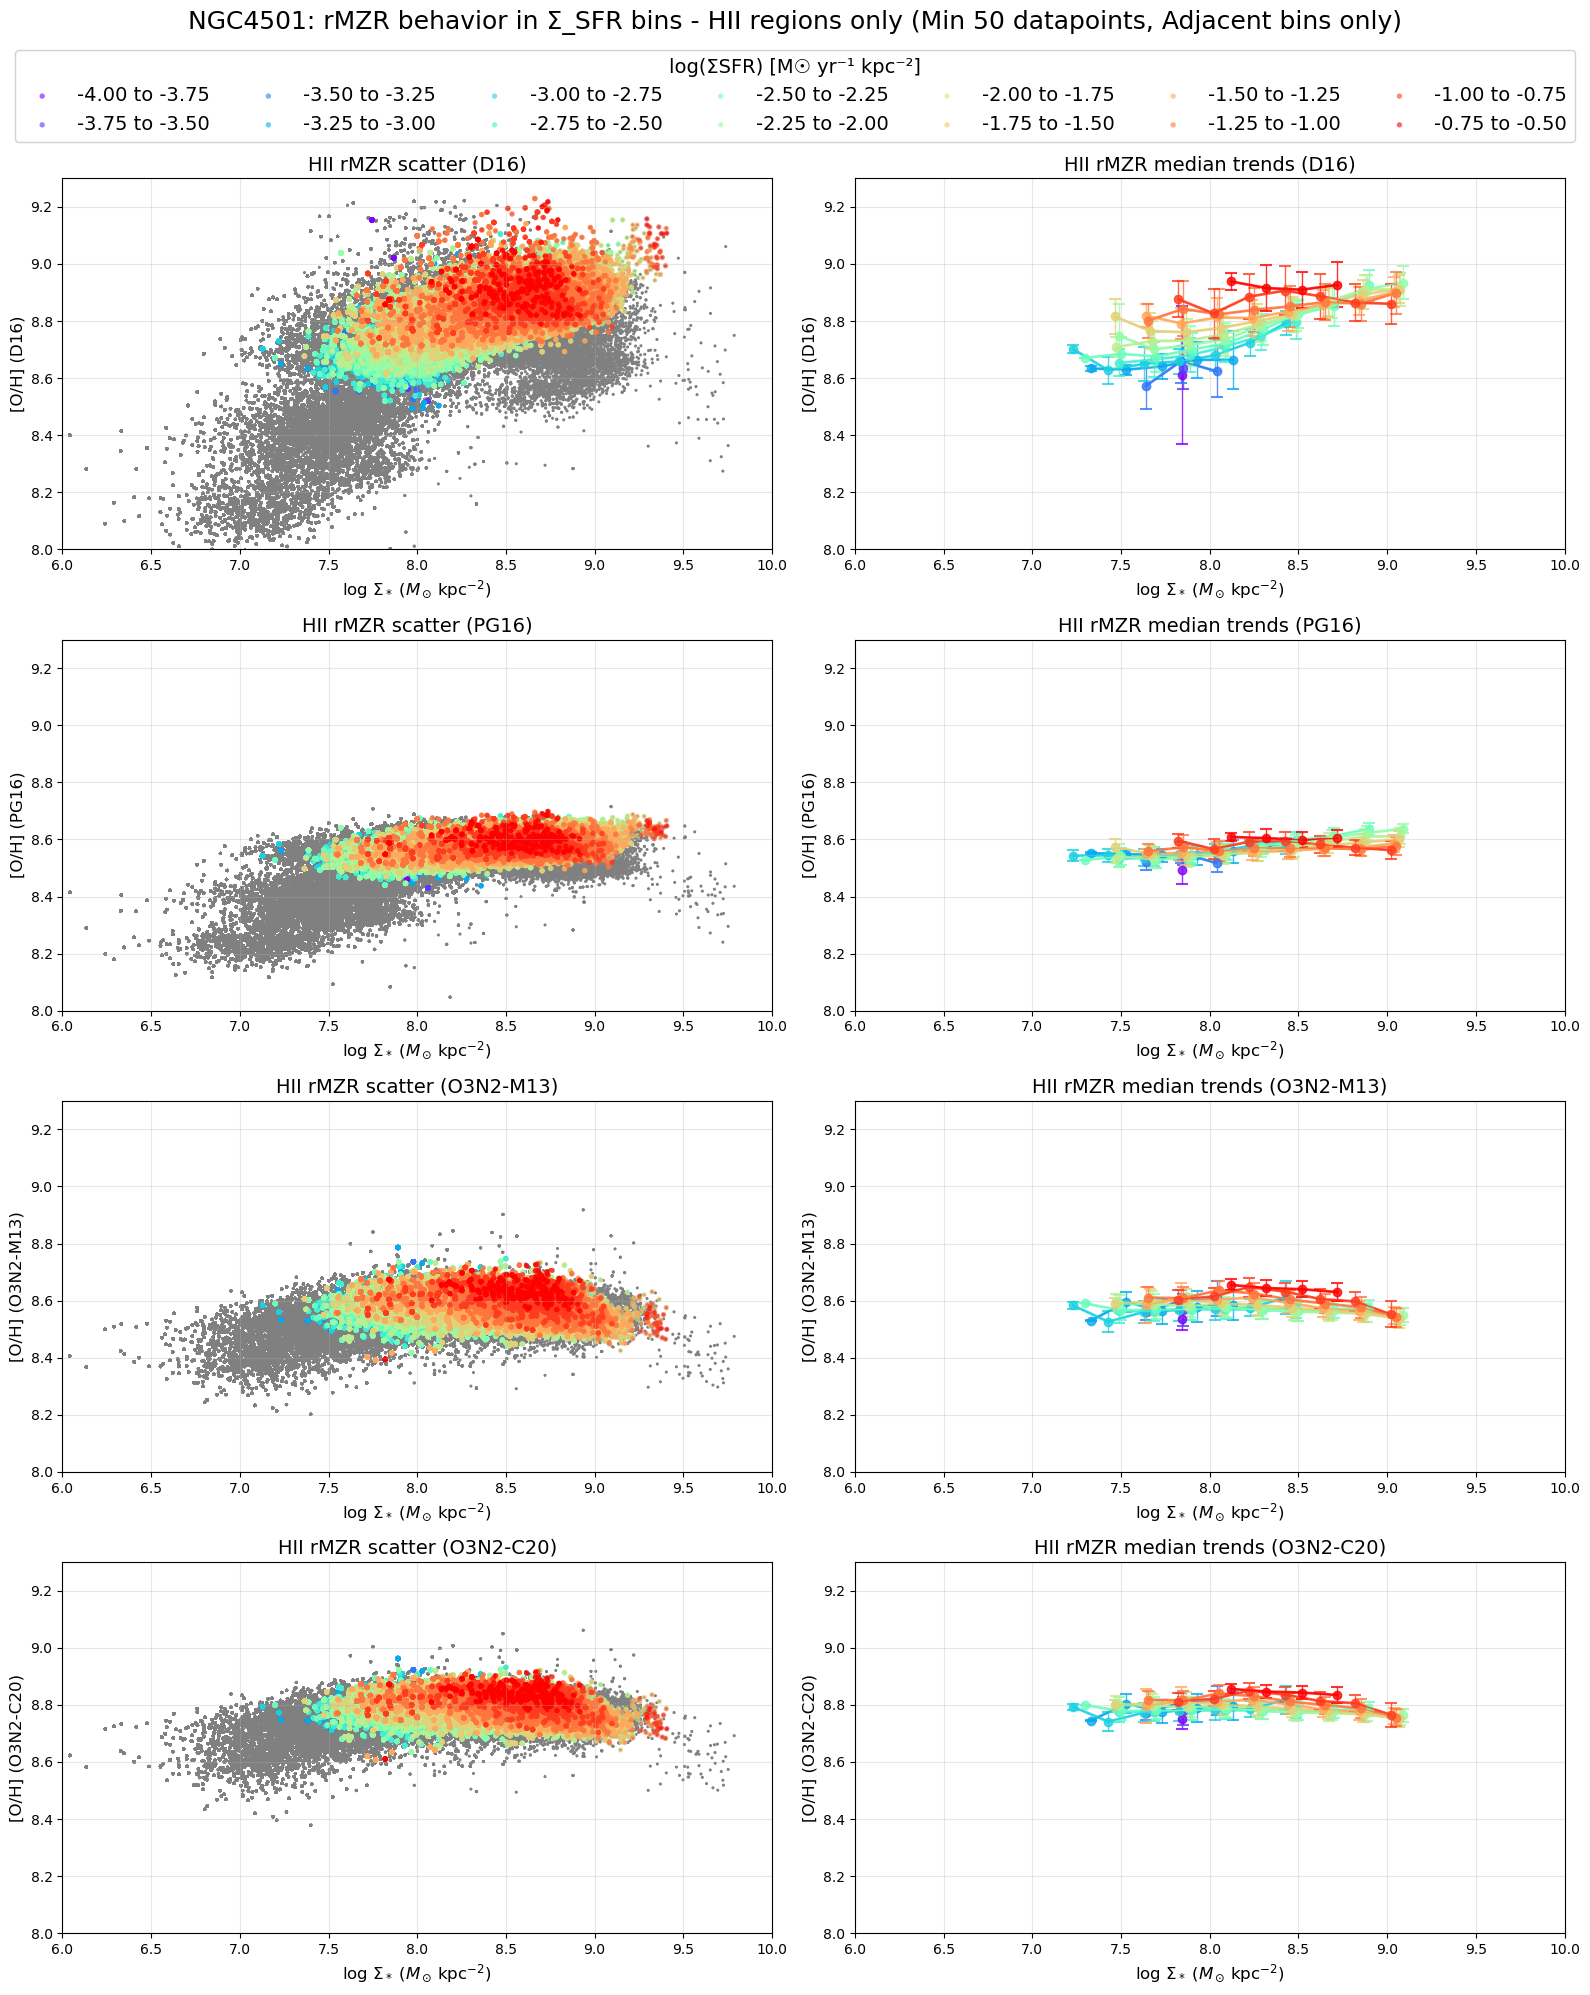


Successfully created 4x2 subplot figure for NGC4501

Processing galaxy: NGC4522
Total HII pixels with all calibrations: 39354

Processing D16 calibration for HII regions:
  HII D16 range: 8.239 to 8.927
  Total valid bins: 12

Processing PG16 calibration for HII regions:
  HII PG16 range: 8.300 to 8.598
Total HII pixels with all calibrations: 39354

Processing D16 calibration for HII regions:
  HII D16 range: 8.239 to 8.927
  Total valid bins: 12

Processing PG16 calibration for HII regions:
  HII PG16 range: 8.300 to 8.598
  Total valid bins: 12

Processing O3N2-M13 calibration for HII regions:
  HII O3N2-M13 range: 8.361 to 8.677
  Total valid bins: 12

Processing O3N2-C20 calibration for HII regions:
  HII O3N2-C20 range: 8.574 to 8.874
  Total valid bins: 12
  Total valid bins: 12

Processing O3N2-M13 calibration for HII regions:
  HII O3N2-M13 range: 8.361 to 8.677
  Total valid bins: 12

Processing O3N2-C20 calibration for HII regions:
  HII O3N2-C20 range: 8.574 to 8.874
  Tota

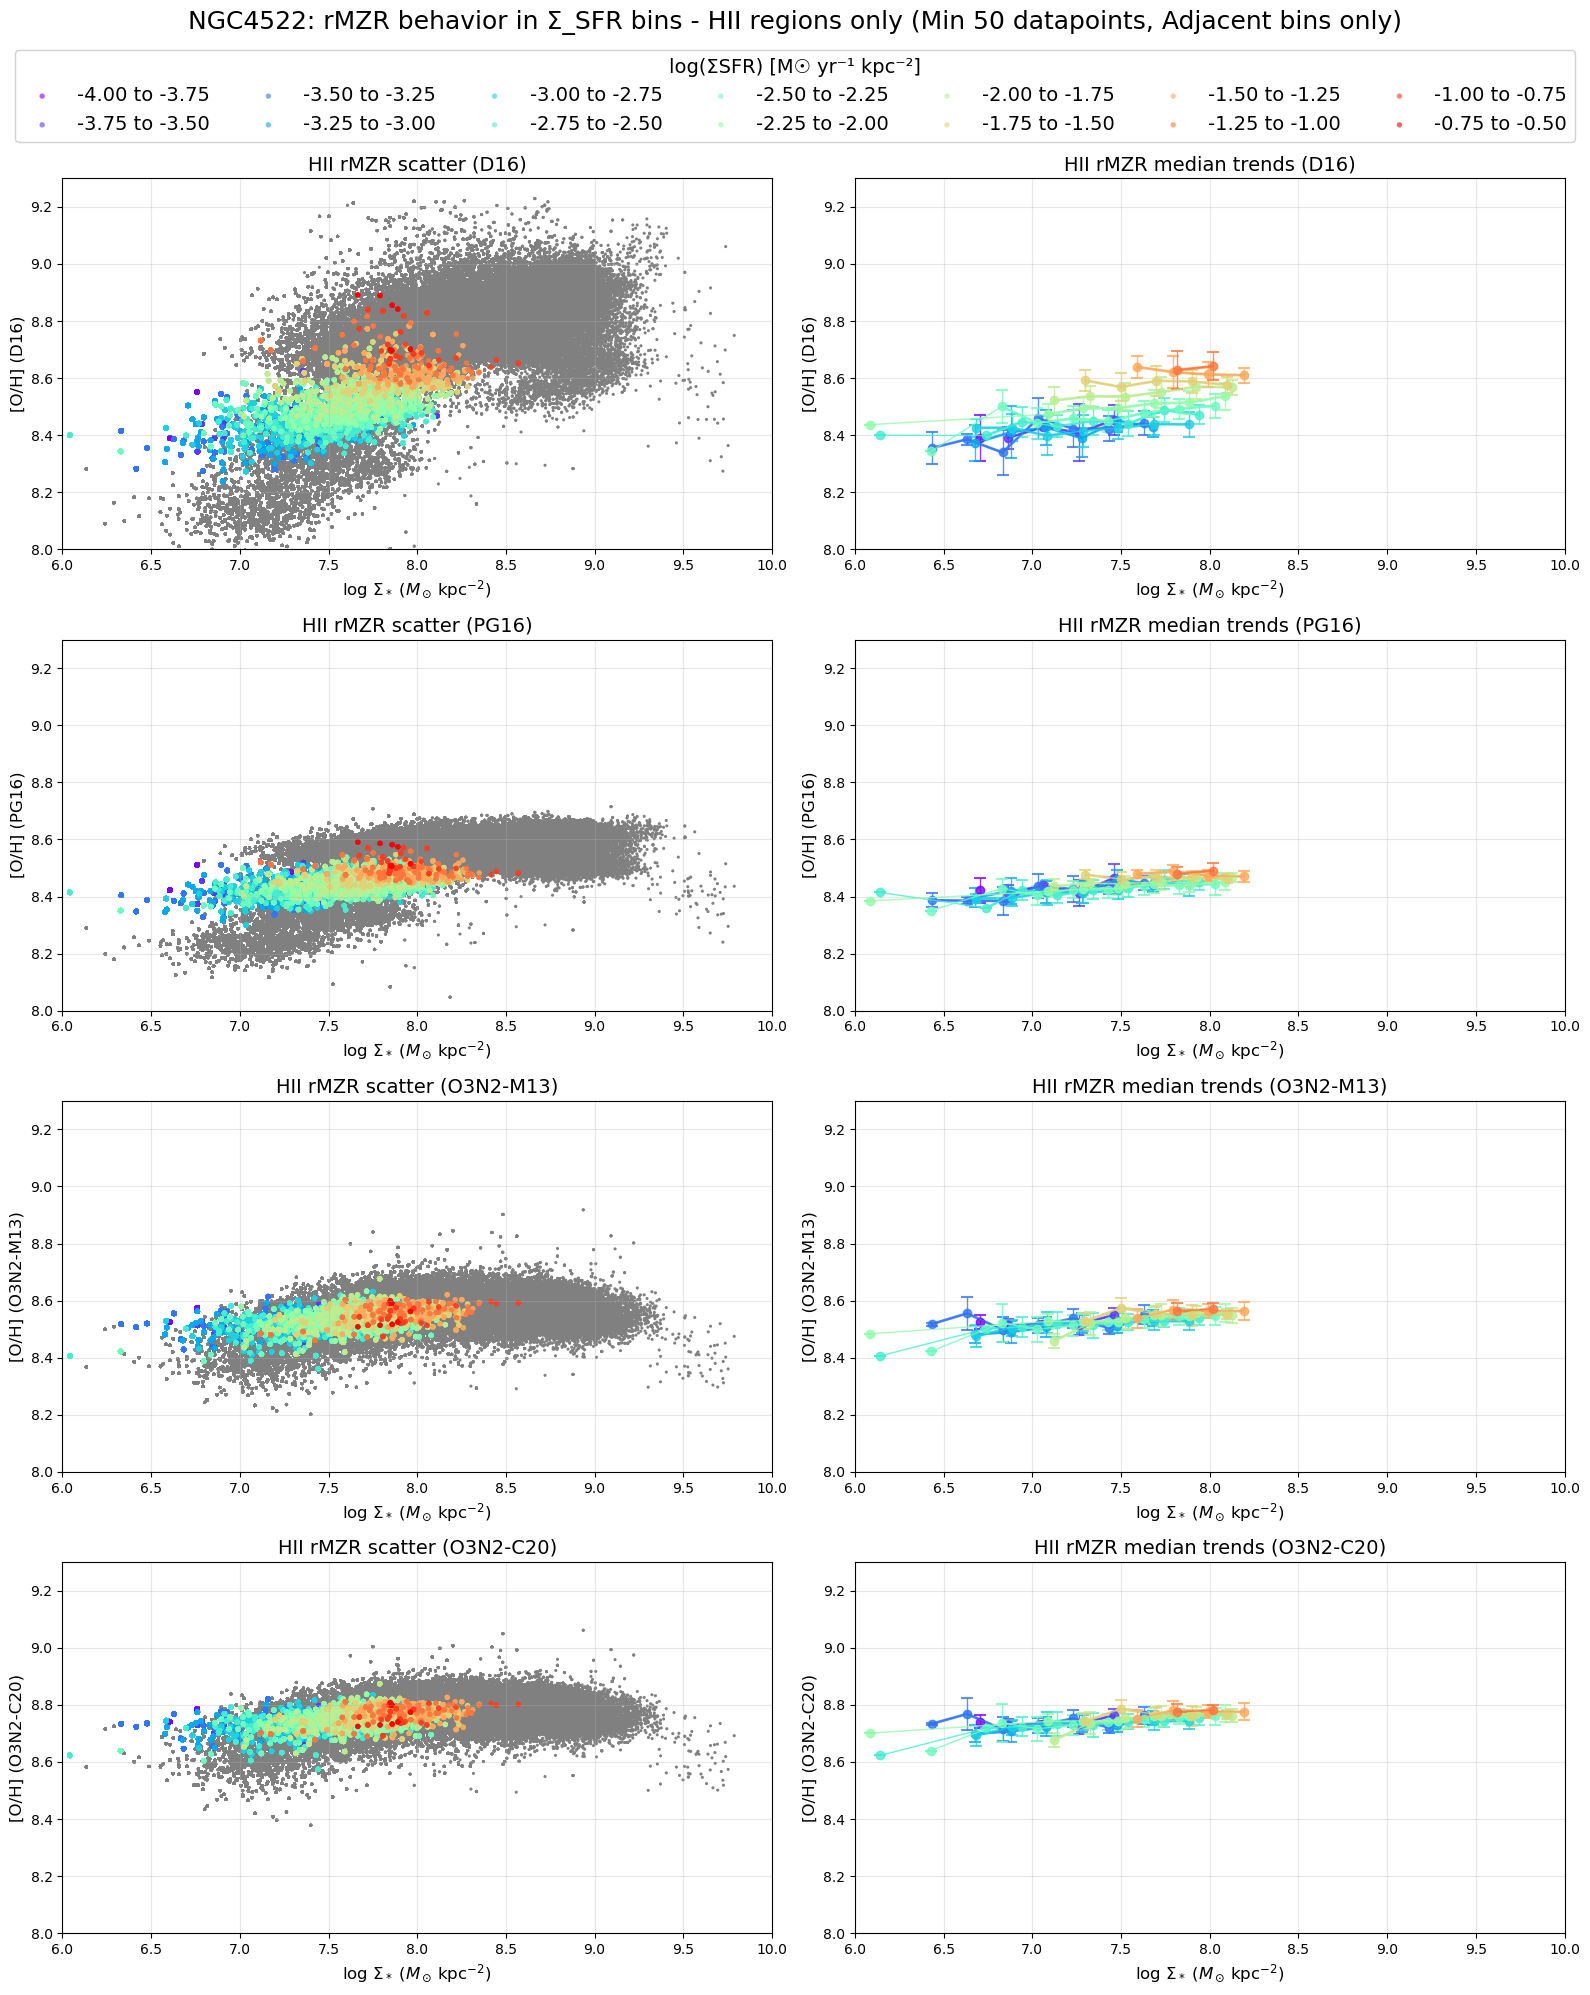


Successfully created 4x2 subplot figure for NGC4522

Processing galaxy: NGC4694
Total HII pixels with all calibrations: 2585

Processing D16 calibration for HII regions:
  HII D16 range: 8.303 to 9.119
  Total valid bins: 7

Processing PG16 calibration for HII regions:
  HII PG16 range: 8.271 to 8.612
  Total valid bins: 7

Processing O3N2-M13 calibration for HII regions:
  HII O3N2-M13 range: 8.381 to 8.641
Total HII pixels with all calibrations: 2585

Processing D16 calibration for HII regions:
  HII D16 range: 8.303 to 9.119
  Total valid bins: 7

Processing PG16 calibration for HII regions:
  HII PG16 range: 8.271 to 8.612
  Total valid bins: 7

Processing O3N2-M13 calibration for HII regions:
  HII O3N2-M13 range: 8.381 to 8.641
  Total valid bins: 7

Processing O3N2-C20 calibration for HII regions:
  HII O3N2-C20 range: 8.595 to 8.844
  Total valid bins: 7
  Total valid bins: 7

Processing O3N2-C20 calibration for HII regions:
  HII O3N2-C20 range: 8.595 to 8.844
  Total valid b

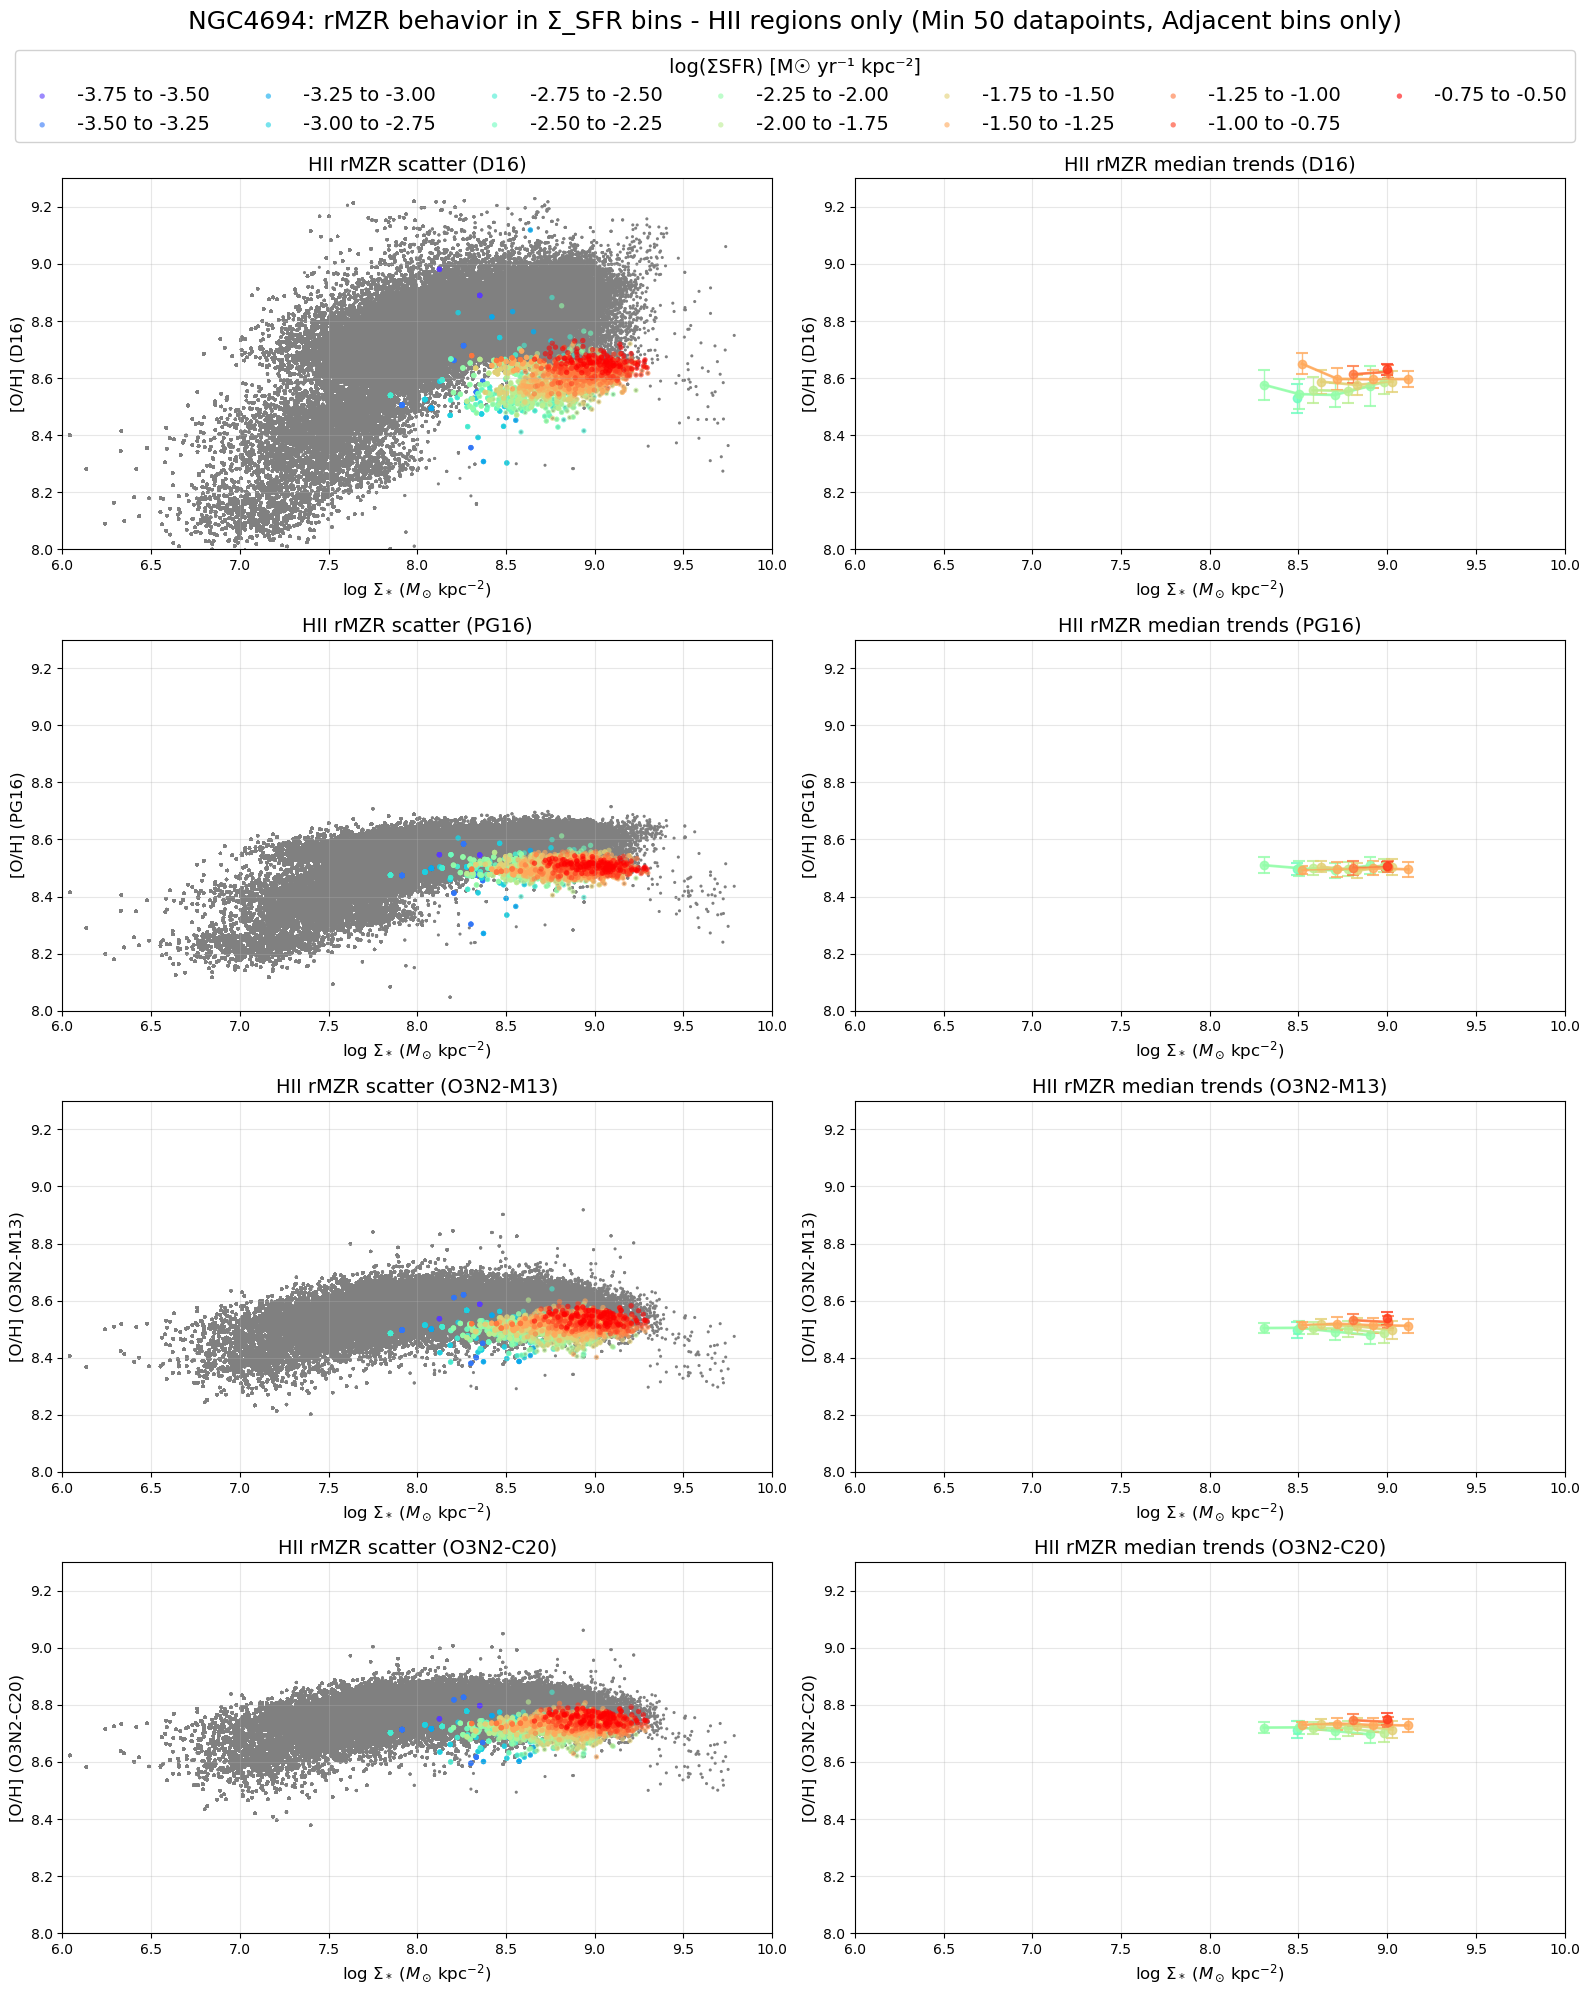


Successfully created 4x2 subplot figure for NGC4694

Processing galaxy: NGC4698
Total HII pixels with all calibrations: 10042

Processing D16 calibration for HII regions:
  HII D16 range: 8.274 to 9.219
  Total valid bins: 9

Processing PG16 calibration for HII regions:
  HII PG16 range: 7.645 to 8.689
  Total valid bins: 9

Processing O3N2-M13 calibration for HII regions:
  HII O3N2-M13 range: 8.297 to 8.778
Total HII pixels with all calibrations: 10042

Processing D16 calibration for HII regions:
  HII D16 range: 8.274 to 9.219
  Total valid bins: 9

Processing PG16 calibration for HII regions:
  HII PG16 range: 7.645 to 8.689
  Total valid bins: 9

Processing O3N2-M13 calibration for HII regions:
  HII O3N2-M13 range: 8.297 to 8.778
  Total valid bins: 9

Processing O3N2-C20 calibration for HII regions:
  HII O3N2-C20 range: 8.500 to 8.956
  Total valid bins: 9
  Total valid bins: 9

Processing O3N2-C20 calibration for HII regions:
  HII O3N2-C20 range: 8.500 to 8.956
  Total valid

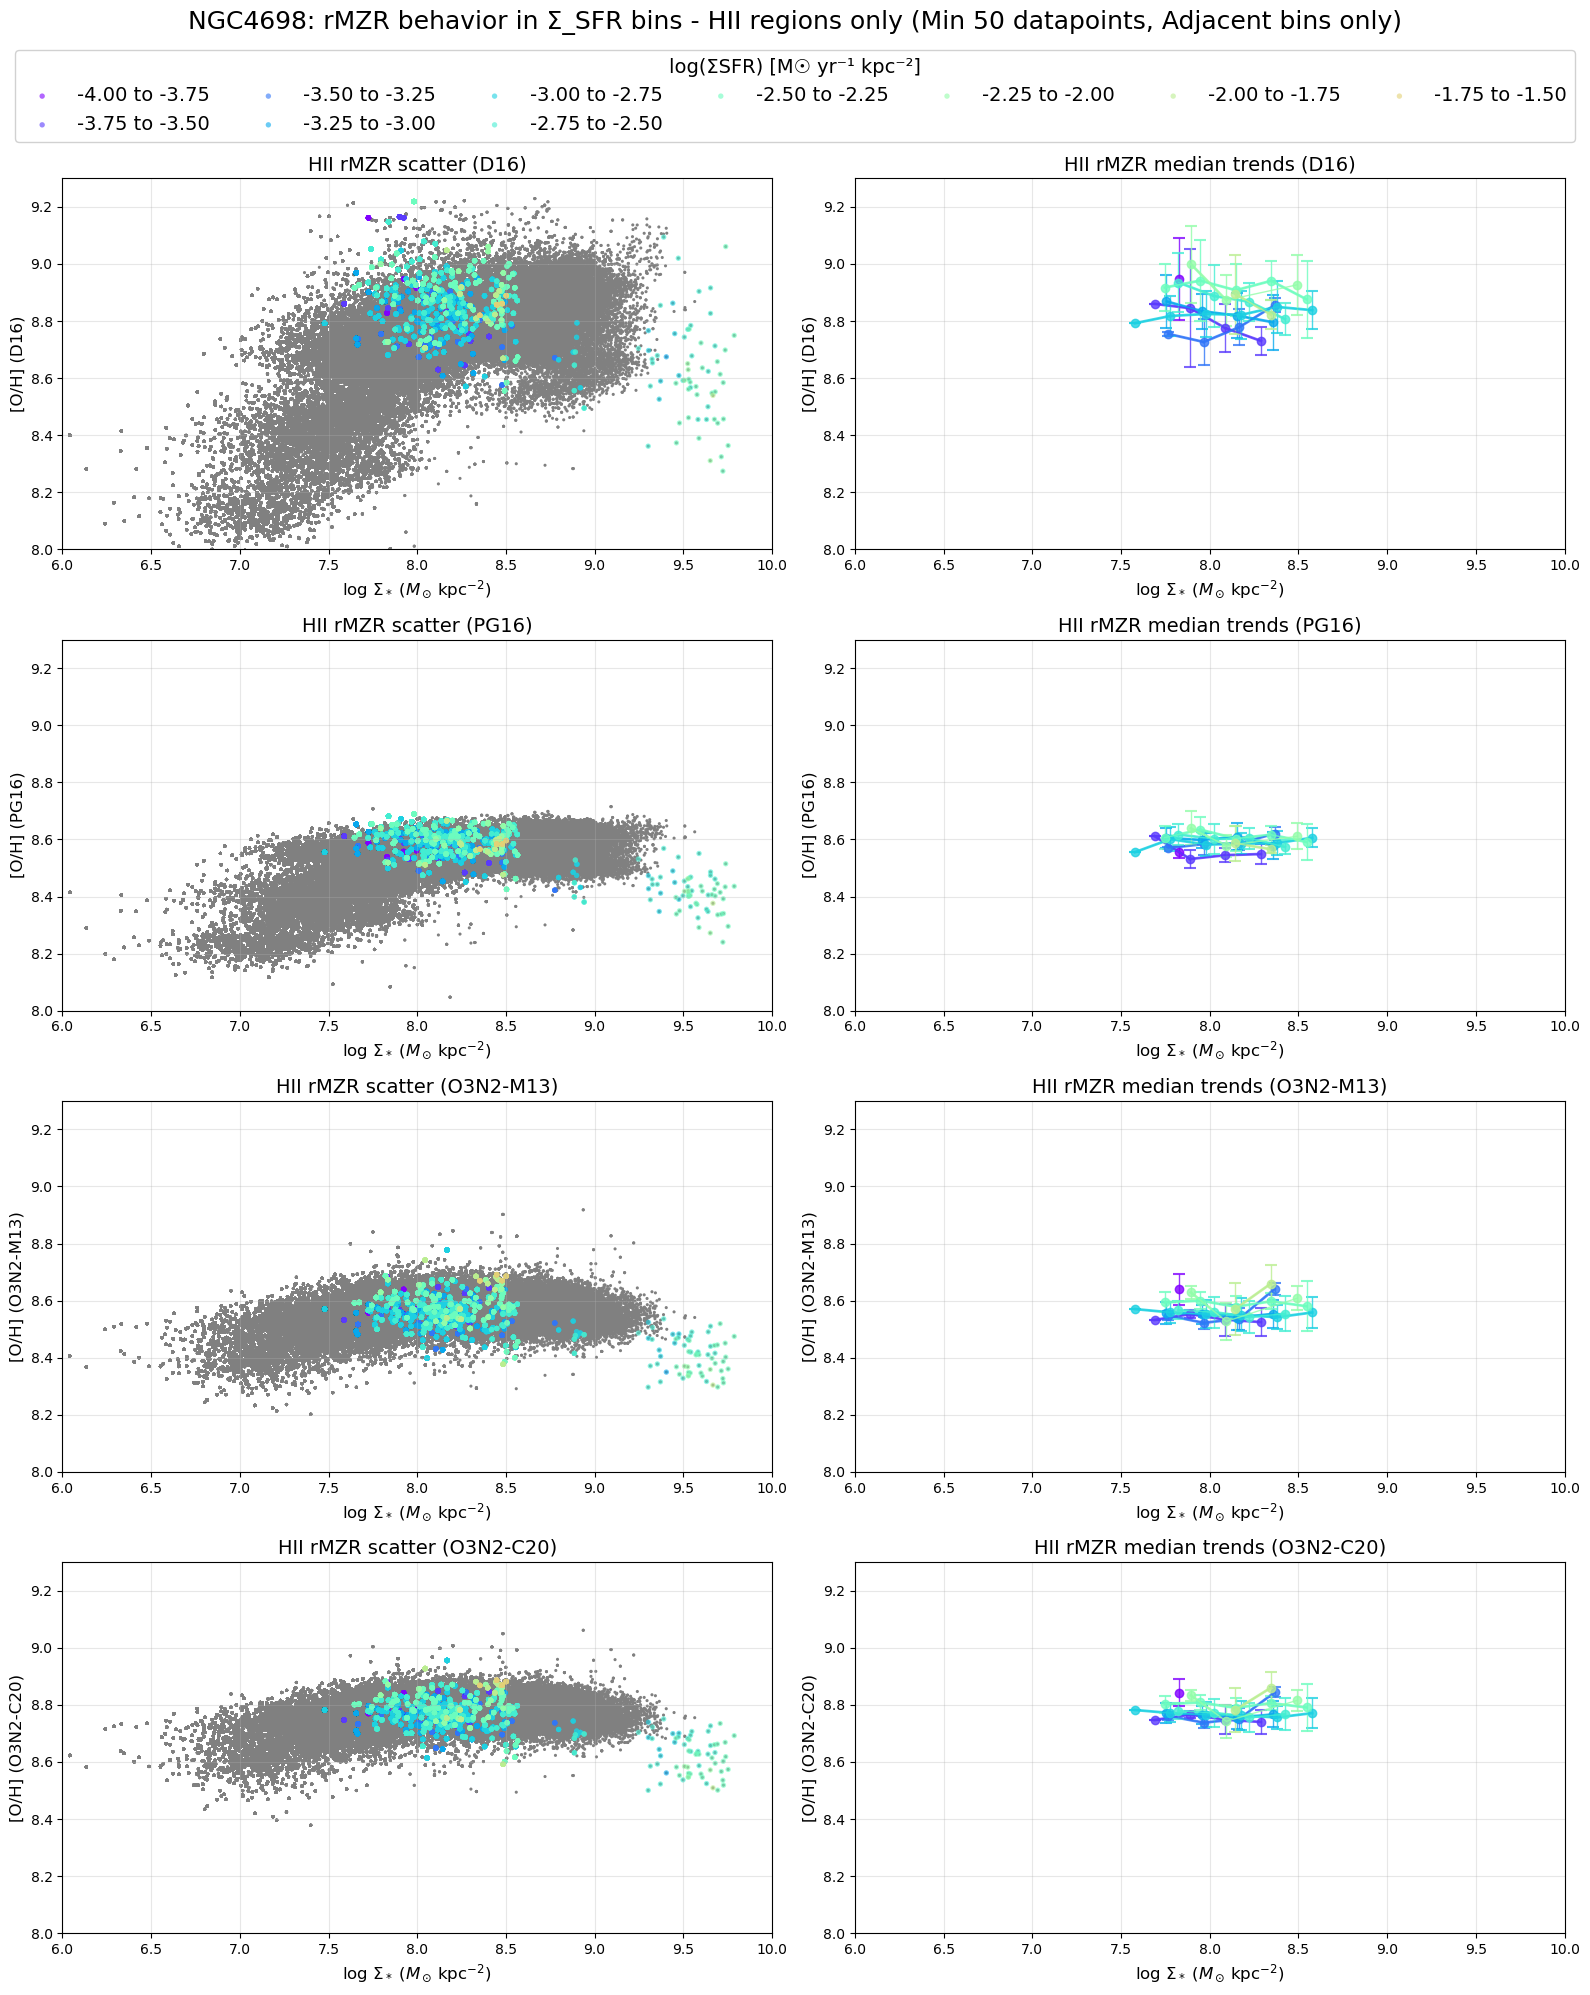


Successfully created 4x2 subplot figure for NGC4698

Finished processing all galaxies


In [ ]:
# ------------------------------------------------------------------
# Individual Galaxy Analysis: rMZR behavior in Σ_SFR bins - HII regions only
# Loop through each galaxy individually
#
# 4 calibrations: D16, PG16, O3N2-M13, O3N2-C20
# Row 1: D16 (scatter left, median right)
# Row 2: PG16 (scatter left, median right)
# Row 3: O3N2-M13 (scatter left, median right)
# Row 4: O3N2-C20 (scatter left, median right)
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats

def load_maps_all_calibrations(gal):
    """Load all metallicity calibrations for HII regions"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        # HII regions
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_d16_HII = h['O_H_D16_HII'].data
        oh_pg16_HII = h['O_H_PG16_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
        oh_o3n2_c20_HII = h['O_H_O3N2_C20_HII'].data
    return (sigM, sigSFR_HII, oh_d16_HII, oh_pg16_HII, oh_o3n2_m13_HII, oh_o3n2_c20_HII)

def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=50):
    """Calculate median and std in stellar mass bins - only keep bins with >= 50 unique datapoints"""
    # Define mass bins
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    mass_bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    mass_bin_centers = (mass_bin_edges[:-1] + mass_bin_edges[1:]) / 2
    
    medians = []
    stds = []
    counts = []
    valid_centers = []
    valid_bin_indices = []
    
    for i, (bin_start, bin_end) in enumerate(zip(mass_bin_edges[:-1], mass_bin_edges[1:])):
        # Select data in this mass bin
        in_mass_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_mass_bin]
        
        if len(y_in_bin) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(mass_bin_centers[i])
            valid_bin_indices.append(i)
    
    return (np.array(valid_centers), np.array(medians), np.array(stds), 
            np.array(counts), np.array(valid_bin_indices))

# Get all galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

# Galaxies to exclude entirely
excluded_galaxies = {'NGC4383'}
included_galaxies = []

# ==============================================================================
# First, collect combined data from all galaxies (for background gray scatter)
# ==============================================================================
print("="*80)
print("STEP 1: Collecting combined data from all galaxies for background...")
print("="*80)

all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_d16_HII = []
all_oh_pg16_HII = []
all_oh_o3n2_m13_HII = []
all_oh_o3n2_c20_HII = []

for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded from combined dataset")
        continue

    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

    if bin_file.exists() and gas_file.exists():
        # Load all data for HII regions
        (logSigmaM, logSigmaSFR_HII, oh_d16_HII, oh_pg16_HII, oh_o3n2_m13_HII, 
         oh_o3n2_c20_HII) = load_maps_all_calibrations(gal)

        # Find common spaxels for HII regions
        common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                           np.isfinite(oh_d16_HII) & np.isfinite(oh_pg16_HII) & 
                           np.isfinite(oh_o3n2_m13_HII) & np.isfinite(oh_o3n2_c20_HII))
        
        print(f"  {gal}: HII={np.sum(common_mask_HII)} pixels")
        
        # Append HII data
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_d16_HII.extend(oh_d16_HII[common_mask_HII].flatten())
        all_oh_pg16_HII.extend(oh_pg16_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
        all_oh_o3n2_c20_HII.extend(oh_o3n2_c20_HII[common_mask_HII].flatten())

# Convert to numpy arrays
all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_d16_HII = np.array(all_oh_d16_HII)
all_oh_pg16_HII = np.array(all_oh_pg16_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)
all_oh_o3n2_c20_HII = np.array(all_oh_o3n2_c20_HII)

# Store combined data in a dictionary for easy access
combined_calib_map = {
    'oh_d16_HII': all_oh_d16_HII,
    'oh_pg16_HII': all_oh_pg16_HII,
    'oh_o3n2_m13_HII': all_oh_o3n2_m13_HII,
    'oh_o3n2_c20_HII': all_oh_o3n2_c20_HII
}

print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")

# ==============================================================================
# Define Σ_SFR bins and plotting parameters
# ==============================================================================
sfr_bin_edges = np.round(np.linspace(-4.0, -0.5, int(((-0.5) - (-4.0)) / 0.25) + 1), 2)
n_bins = len(sfr_bin_edges) - 1

# Colors for different bins
colors = plt.cm.rainbow(np.linspace(0, 1, n_bins))

# Set uniform y-axis range
common_ylim = (8.0, 9.3)

print(f"\nUsing uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

# Data for each calibration
calibrations = [
    ('oh_d16_HII', 'D16'),
    ('oh_pg16_HII', 'PG16'),
    ('oh_o3n2_m13_HII', 'O3N2-M13'),
    ('oh_o3n2_c20_HII', 'O3N2-C20')
]

# ==============================================================================
# STEP 2: Loop through each galaxy and plot individual data + combined background
# ==============================================================================
print("\n" + "="*80)
print("STEP 2: Processing individual galaxies...")
print("="*80)

for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"\n{'='*80}")
        print(f"Skipping {gal} (excluded from analysis)")
        print(f"{'='*80}")
        continue

    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

    if not (bin_file.exists() and gas_file.exists()):
        print(f"\n{'='*80}")
        print(f"Skipping {gal} (data files not found)")
        print(f"{'='*80}")
        continue

    print(f"\n{'='*80}")
    print(f"Processing galaxy: {gal}")
    print(f"{'='*80}")

    # Load all data for this galaxy
    (logSigmaM, logSigmaSFR_HII, oh_d16_HII, oh_pg16_HII, oh_o3n2_m13_HII, 
     oh_o3n2_c20_HII) = load_maps_all_calibrations(gal)

    # Find common spaxels for HII regions
    common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                       np.isfinite(oh_d16_HII) & np.isfinite(oh_pg16_HII) & 
                       np.isfinite(oh_o3n2_m13_HII) & np.isfinite(oh_o3n2_c20_HII))
    
    n_pixels_total = np.sum(common_mask_HII)
    print(f"Total HII pixels with all calibrations: {n_pixels_total}")
    
    if n_pixels_total == 0:
        print(f"No valid pixels for {gal}, skipping...")
        continue

    # Get flattened arrays for this galaxy
    gal_logSigmaM = logSigmaM[common_mask_HII].flatten()
    gal_logSigmaSFR_HII = logSigmaSFR_HII[common_mask_HII].flatten()
    gal_oh_d16_HII = oh_d16_HII[common_mask_HII].flatten()
    gal_oh_pg16_HII = oh_pg16_HII[common_mask_HII].flatten()
    gal_oh_o3n2_m13_HII = oh_o3n2_m13_HII[common_mask_HII].flatten()
    gal_oh_o3n2_c20_HII = oh_o3n2_c20_HII[common_mask_HII].flatten()

    # Map calibration variable names to actual data for this galaxy
    calib_data_map = {
        'oh_d16_HII': gal_oh_d16_HII,
        'oh_pg16_HII': gal_oh_pg16_HII,
        'oh_o3n2_m13_HII': gal_oh_o3n2_m13_HII,
        'oh_o3n2_c20_HII': gal_oh_o3n2_c20_HII
    }

    # Create figure with 4 rows x 2 columns 
    fig, axes = plt.subplots(4, 2, figsize=(16, 20))

    # Create legend handles (will be populated during first row)
    legend_handles = []
    legend_labels = []

    # Process each row (1 calibration per row)
    for row_idx, (calib_key, calib_name_HII) in enumerate(calibrations):
        print(f"\nProcessing {calib_name_HII} calibration for HII regions:")
        
        # Get the data for this calibration (individual galaxy)
        oh_data_HII = calib_data_map[calib_key]
        
        # Get the combined data for this calibration (all galaxies)
        oh_combined_HII = combined_calib_map[calib_key]
        
        # Column 0: Scatter plot, Column 1: Median trends
        ax_scatter = axes[row_idx, 0]
        ax_median = axes[row_idx, 1]
        
        print(f"  HII {calib_name_HII} range: {np.min(oh_data_HII):.3f} to {np.max(oh_data_HII):.3f}")
        
        # FIRST: Plot combined galaxy data as gray background
        ax_scatter.scatter(all_logSigmaM_HII, oh_combined_HII, 
                         c='gray', s=5, alpha=1.0, edgecolors='none', 
                         rasterized=True, label='All galaxies')
        
        # SECOND: Plot each Σ_SFR bin for this individual galaxy
        valid_bins = 0
        
        for i, (bin_start, bin_end) in enumerate(zip(sfr_bin_edges[:-1], sfr_bin_edges[1:])):
            # HII regions processing
            in_bin_HII = (gal_logSigmaSFR_HII >= bin_start) & (gal_logSigmaSFR_HII < bin_end)
            n_pixels_HII = np.sum(in_bin_HII)
            
            if n_pixels_HII >= 10:  # Process bins with enough pixels
                # Get data for this bin
                x_bin_HII = gal_logSigmaM[in_bin_HII]
                y_bin_HII = oh_data_HII[in_bin_HII]
                
                # Scatter plot (individual galaxy on top of gray background)
                scatter_hii = ax_scatter.scatter(x_bin_HII, y_bin_HII, c=[colors[i]], s=15, alpha=0.6, 
                                     edgecolors='none', rasterized=True)
                
                # Collect legend info only from first row
                if row_idx == 0 and len(legend_handles) < n_bins:
                    legend_handles.append(scatter_hii)
                    legend_labels.append(f'{bin_start:.2f} to {bin_end:.2f}')
                
                # Median trends
                mass_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
                    x_bin_HII, y_bin_HII, bin_width=0.2, min_pixels=50)
                
                if len(mass_centers_HII) > 0:
                    ax_median.errorbar(mass_centers_HII, medians_HII, yerr=stds_HII, 
                               color=colors[i], marker='o', markersize=6, 
                               linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
                    
                    # Add lines between adjacent bins
                    for j in range(len(valid_bin_indices_HII) - 1):
                        current_bin_idx = valid_bin_indices_HII[j]
                        next_bin_idx = valid_bin_indices_HII[j + 1]
                        if next_bin_idx - current_bin_idx == 1:
                            ax_median.plot([mass_centers_HII[j], mass_centers_HII[j + 1]], 
                                   [medians_HII[j], medians_HII[j + 1]], 
                                   color=colors[i], linewidth=2, alpha=0.8)
                    valid_bins += 1
        
        # Format scatter plot
        ax_scatter.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
        ax_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
        ax_scatter.set_title(f'HII rMZR scatter ({calib_name_HII})', fontsize=14)
        ax_scatter.grid(True, alpha=0.3)
        ax_scatter.set_xlim(6, 10)
        ax_scatter.set_ylim(common_ylim)
        
        # Format median trends plot
        ax_median.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
        ax_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
        ax_median.set_title(f'HII rMZR median trends ({calib_name_HII})', fontsize=14)
        ax_median.grid(True, alpha=0.3)
        ax_median.set_xlim(6, 10)
        ax_median.set_ylim(common_ylim)
        
        print(f"  Total valid bins: {valid_bins}")

    # Add overall title and adjust layout
    fig.suptitle(f'{gal}: rMZR behavior in Σ_SFR bins - HII regions only (Min 50 datapoints, Adjacent bins only)', 
                 fontsize=18, y=0.995)

    # Add shared legend at the top horizontally
    fig.legend(legend_handles, legend_labels, loc='upper center', bbox_to_anchor=(0.5, 0.98),
              ncol=min(len(legend_labels), 7), fontsize=14, framealpha=0.9, 
              title='log(ΣSFR) [M☉ yr⁻¹ kpc⁻²]', title_fontsize=14)

    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for suptitle and legend
    # plt.savefig(f'{gal}_rMZR_HII_only_4calibrations_4x2grid.png', dpi=300, bbox_inches='tight')
    # plt.savefig(f'{gal}_rMZR_HII_only_4calibrations_4x2grid.pdf', bbox_inches='tight')
    plt.show()

    print(f"\nSuccessfully created 4x2 subplot figure for {gal}")

print(f"\n{'='*80}")
print("Finished processing all galaxies")
print(f"{'='*80}")
